# Steel-making: ore → billet → and what goes wrong

*A guided what-if over the validated **front-end** production chain — the twin of the back-end
`steel.ipynb` (cooling curve in, microstructure out).*

`steel.ipynb` starts from a *finished grade* and asks how to heat-treat it. **This notebook is
everything that happens first** — how the grade gets made, and what the chemistry comes back to
inflict when it is off. Two halves, one thread:

1. **Make it** — ore → iron → steel → billet: reduction (F1), the `Heat` spine, primary refining
   + slag partition (F2), ladle trim to grade (F3), casting + solidification (F4).
2. **Break it** — the defect consequences the upstream chemistry (P, S, O, H, V, carbon) sets up:
   cold-short, red-short, temper embrittlement, tempered-martensite embrittlement, hydrogen
   flaking, gas porosity, hot-tearing, peritectic cracking — and the two *signed* foils where the
   impurity cuts both ways (free-machining MnS, Damascus carbide banding).

The thread tying both halves together is one rule: **an upstream mistake propagates.** Under-dose
the alloy, miss the trim, leave the oxygen in — and the *same* downstream quench or casting lands a
soft core, a blown casting, a cracked forging. The back end is the judge; the front end is where the
verdict is decided.

Every number here is produced by a function **validated in isolation** (`steel/…`, each with its own
test triad). The notebook is a *thin skin*: each compute cell calls the headless `reduction` /
`refining` / `slag` / `ladle` / `casting` / `heat_state` harness (and the consequence modules)
directly — in fact it reuses the very same tested **readout helpers** the Streamlit apps
(`app_making.py`, `app_consequences.py`) use. Per [ADR 0002](../docs/decisions/0002-visualization-and-ux.md)
the figures *consume* validated arrays — they are reach, not evidence.

## Start here — the 30-second mental model

New to steel-making? Read this once and the sections below will click.

**Steel is iron with a little carbon, made clean.** Iron ore is iron *oxide*; you pull the oxygen
off it with carbon (the blast furnace), then you have to get the carbon back *down* to the grade you
want and pull out the impurities the ore left behind. Each stage is a knob, and the notebook gives
you one section per stage:

| Stage | What it does | Section |
|---|---|---|
| **Reduction (F1)** | strip the oxygen off the ore with carbon → liquid iron | §F1 |
| **The spine** | carry the chemistry-state forward so a mistake can *propagate* | §spine |
| **Refining (F2)** | burn the carbon down, kill the dissolved oxygen, partition P/S into slag | §F2a, §F2b |
| **Ladle trim (F3)** | add ferroalloys to hit the grade — and the two ways it misses | §F3–§F3c |
| **Casting (F4)** | freeze it into a billet — where segregation is locked in | §F4a, §F4b |
| **…and what goes wrong** | the defects the chemistry comes back to inflict | §D1–§D9 |

**Mini-glossary** — the words the figures use:

- **Ellingham diagram** — free-energy lines that say *which* element pulls oxygen off *which* oxide,
  above *which* temperature. Carbon's line dives under iron's at ~750 °C — where ironmaking starts.
- **Deoxidation / "killing"** — adding Al/Si/Mn to a steel bath to mop up dissolved oxygen so it
  doesn't blow CO bubbles when the steel freezes.
- **Slag** — the molten oxide layer on the bath; a *basic* slag pulls phosphorus out, a killed ladle
  pulls sulfur out.
- **Partition ratio (L)** — how strongly an impurity prefers the slag over the steel.
- **Recovery** — the fraction of a ferroalloy addition that actually lands in the bath (the rest
  oxidizes off); miss it and the heat lands off-grade.
- **Segregation (Scheil)** — as a casting freezes, the last liquid to solidify (the centerline) is
  enriched in solutes, so one casting is *not* uniform.
- **Cold-short / red-short** — brittle cold (phosphorus) / tears hot when forged (sulfur).
- **Signed impurity** — the same element can be an asset *and* a liability: MnS machines well but
  cuts through-thickness toughness; a trace of vanadium fails a clean spec yet *makes* the Damascus
  pattern. The front end is where you decide which sign you get.

The one rule of thumb the whole notebook makes concrete: **the front end sets the chemistry; the
back end (or the casting) delivers the verdict — and the same impurity can pass one test and fail
the next, because the *other* variable decides.**

## Setup

Imports + the inline backend. The bootstrap walks up to the repo root so `steel…` imports whether
you launched Jupyter from the repo root or from `steel/`. Needs the `viz` + `notebook` extras:
`pip install -e .[viz,notebook]`.

The compute helpers are imported straight from the two tested apps (`app_making`, `app_consequences`)
— their readout functions are pure (Streamlit is imported lazily inside `main()`), so this notebook
turns the *same* validated knobs the apps do, with no duplicated logic and no re-typed scenario
constants (so e.g. the deliberately-restricted tempered-martensite grade set comes along for free).

> **The code cells are collapsed by default** so this reads as a narrative of figures and verdicts.
> Click the **▸ arrow** on the left of a cell to see the actual harness call behind any output.
> **Run → Run All Cells** first.

In [1]:
%matplotlib inline
import sys
from pathlib import Path

# Make `steel...` importable regardless of the launch directory.
for _root in (Path.cwd(), *Path.cwd().parents):
    if (_root / "pyproject.toml").exists():
        if str(_root) not in sys.path:
            sys.path.insert(0, str(_root))
        break

import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import interact

# The tested readout helpers (pure — no streamlit/matplotlib at import) + the banked knob bounds.
from steel import app_making as M
from steel import app_consequences as C
from steel import plots

KNOB = "#b03a2e"  # slider handle colour — visible on the white figure background


def _mark(bad):
    return "✗" if bad else "✓"  # ✗ when the flag says the heat FAILED, ✓ when it passed


## §F1 · Reduction — can carbon pull the oxygen off iron?

The front end begins in the blast furnace. Iron ore is iron *oxide*; making iron means **reducing**
it — stripping the oxygen off — and the reductant of choice is carbon (as CO). The
[Ellingham diagram](demo_reduction.py) plots the free energy of each *metal + oxygen → oxide*
reaction against temperature: the **lower** a line, the more stable its oxide, the harder it is to
reduce. Carbon's `C → CO` line *slopes the opposite way* and dives **under** the iron-oxide lines at
**~750 °C** — above that crossover, carbon spontaneously pulls the last oxygen off iron and ironmaking
is thermodynamically downhill. The same ladder explains the *deoxidizer* order downstream: Ca and Al
sit far below Fe (their oxides are very stable), so they scavenge oxygen out of a steel bath that Fe,
Mn, Si cannot — the order §F2a reads. The 746 °C crossover is the demo's benchmark tooth.

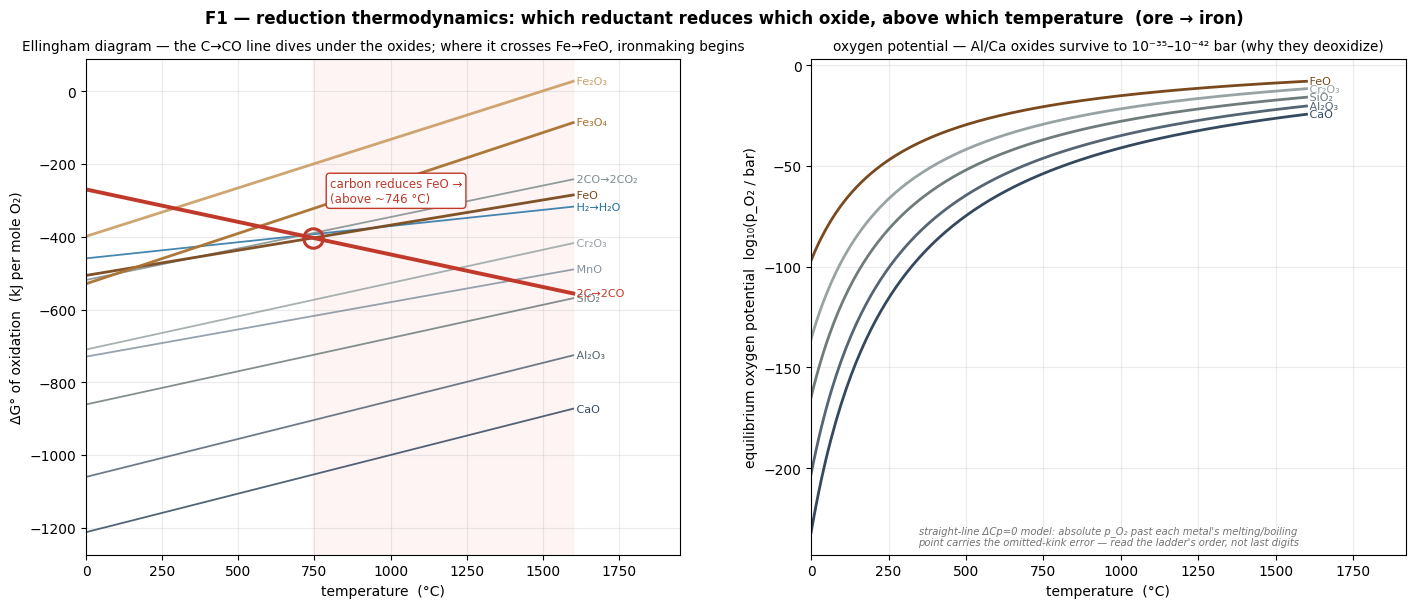

at 1200 °C:  C→CO -484 kJ/mol O₂   |   Fe→FeO -340 kJ/mol O₂
   ✓ carbon (→CO) reduces wüstite — ironmaking is spontaneous here
   crossover (C reduces wustite above): 746 °C
   oxide stability, most stable first (the deoxidizer ladder): Ca->CaO < Al->Al2O3 < Si->SiO2 < Mn->MnO < Cr->Cr2O3 < Fe->FeO


In [2]:
from steel.demo_reduction import compute as red_compute

fig = plots.ellingham_figure(red_compute())          # the banked Ellingham diagram (gallery figure)
plt.show()

rr = M.reduction_readout(1200.0)                     # direct, validated call — at 1200 °C
print(f"at {rr['T_C']:.0f} °C:  C→CO {rr['g_carbon']}   |   Fe→FeO {rr['g_wustite']}")
print(f"   {_mark(not rr['carbon_reduces_wustite'])} {rr['verdict']}")
print(f"   crossover (C reduces wustite above): {rr['crossover_C']:.0f} °C")
print(f"   oxide stability, most stable first (the deoxidizer ladder): "
      + " < ".join(rr['hierarchy_order']))

In [3]:
# Live: sweep the furnace temperature across the carbon/iron-oxide crossover.
def _f1(T):
    r = M.reduction_readout(float(T))
    print(f"{_mark(not r['carbon_reduces_wustite'])} {r['verdict']}")
    print(f"   C→CO {r['g_carbon']}   vs   Fe→FeO {r['g_wustite']}   (crossover {r['crossover_C']:.0f} °C)")

interact(_f1, T=widgets.FloatSlider(value=1200, min=M.RED_T_MIN, max=M.RED_T_MAX, step=25,
         description="furnace °C", continuous_update=False, style={"handle_color": KNOB}));

interactive(children=(FloatSlider(value=1200.0, continuous_update=False, description='furnace °C', max=1600.0,…

## §spine · The `Heat` spine — an upstream mistake propagates to a downstream defect

The stages compose by handing each other a `Heat` — an immutable record of the chemistry-state so far
(composition + the gas/inclusion fields + a provenance trail). That is what lets a *front-end* mistake
become a *back-end* defect with no scripting. Here is the hero: take a 4140, keep manganese on spec,
but **under-dose the deep-hardening Cr/Mo**, then run the *same* oil quench a proper 4140 gets. The
[propagation demo](demo_heat_state.py) shows it — the well-dosed heat through-hardens; the under-dosed
one leaves a soft, ferrite-dominant core. The soft-core flag is **not** scripted: it is the back-end
martensite fraction crossing a labelled spec line, carried on the `Heat`.

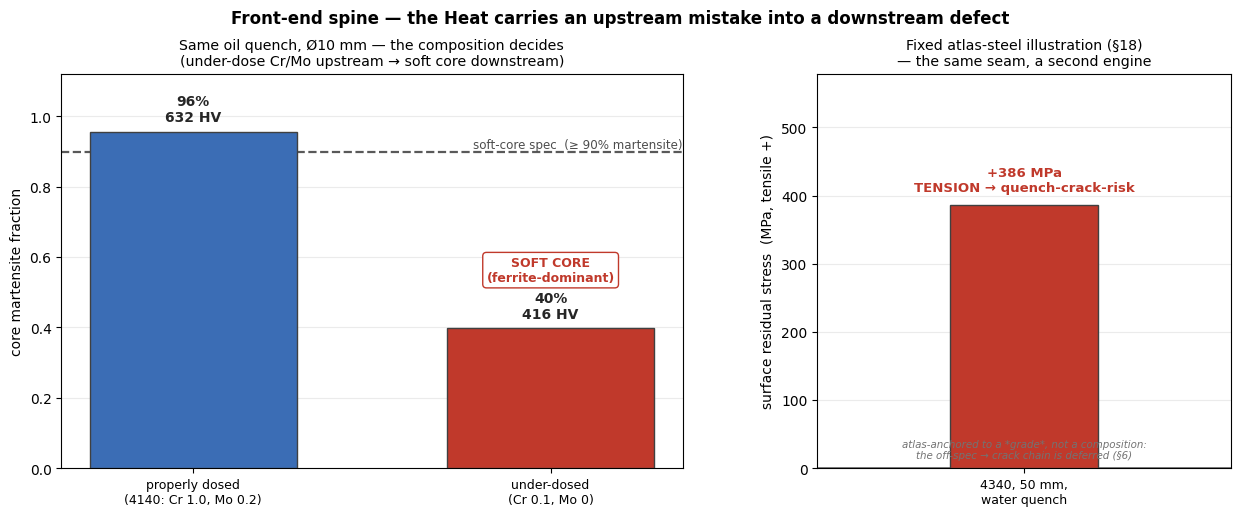

   ✓ on-spec  (Cr 1.00, Mo 0.20): through-hardens — 96% martensite, clears the 90% spec
   ✗ under-dosed (Cr 0.35, Mo 0.05): soft core — only 80% martensite, under the 90% spec (the under-dose propagated to a defect)
   same oil quench, same section — only the chemistry differs; the flag is emergent, not scripted.


In [4]:
from steel.demo_heat_state import compute as hs_compute

fig = plots.heat_state_figure(hs_compute())          # well-dosed vs under-dosed, same quench
plt.show()

ok   = M.spine_readout(M.SPINE_CR_NOMINAL, M.SPINE_MO_NOMINAL)   # on-spec 4140
bad  = M.spine_readout(0.35, 0.05)                               # under-dosed Cr/Mo
print(f"   {_mark(ok['soft_core'])} on-spec  (Cr 1.00, Mo 0.20): {ok['verdict']}")
print(f"   {_mark(bad['soft_core'])} under-dosed (Cr 0.35, Mo 0.05): {bad['verdict']}")
print("   same oil quench, same section — only the chemistry differs; the flag is emergent, not scripted.")

In [5]:
# Live: dose Cr/Mo on the 4140 and watch the core cross the martensite spec.
def _spine(Cr, Mo):
    r = M.spine_readout(Cr, Mo)
    print(f"{_mark(r['soft_core'])} {r['verdict']}")
    print(f"   core: {r['martensite_str']}, {r['HV_str']}   (spec {r['spec_str']})")

interact(_spine,
         Cr=widgets.FloatSlider(value=M.SPINE_CR_NOMINAL, min=0.0, max=1.20, step=0.05,
                                description="Cr %", continuous_update=False, style={"handle_color": KNOB}),
         Mo=widgets.FloatSlider(value=M.SPINE_MO_NOMINAL, min=0.0, max=0.30, step=0.01,
                                description="Mo %", continuous_update=False, style={"handle_color": KNOB}));

interactive(children=(FloatSlider(value=1.0, continuous_update=False, description='Cr %', max=1.2, step=0.05, …

## §F2a · Refining — kill the dissolved oxygen (and why aluminium has a sweet spot)

After the blow drops carbon to grade, the bath is saturated with dissolved **oxygen** that must be
removed before casting or it blows CO holes (§D5). You "kill" the steel by adding a deoxidizer whose
oxide is more stable than FeO — and the [Ellingham ladder](demo_reduction.py) from §F1 already told us
the order: **Al ≫ Si > Mn**. The [refining demo](demo_refining.py) fills the dissolved O/H/N fields the
`Heat` carried empty. The twist: aluminium's curve bends through a **minimum** (~0.074 %) because of the
Sigworth–Elliott interaction — below it, *more* aluminium re-raises oxygen — so the "ignore the
interaction" cartoon and the real curve disagree, and the disagreement *is* the minimum.

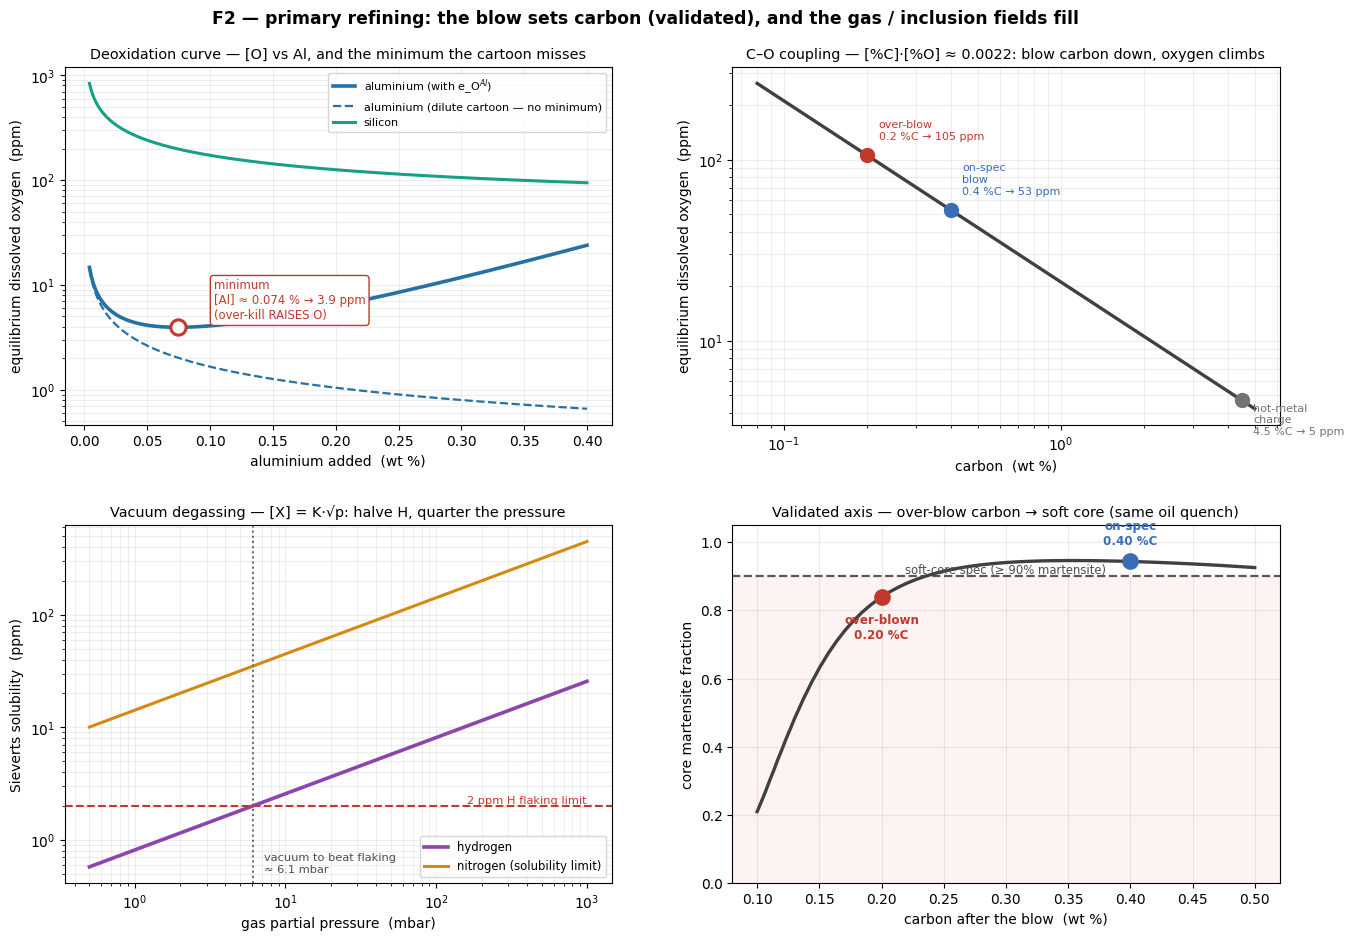

   aluminium at 0.05 %: 4 ppm O   (ignoring the interaction: 3 ppm O)
   [Al] ≈ 0.074 % → 4 ppm O (the curve's floor)
   deoxidizing power, strongest first: Al (4 ppm), Si (240 ppm), Mn (9,390 ppm)
   C–O product benchmark [%C][%O] ≈ 0.0021  (cf. measured BOF/EAF)


In [6]:
from steel.demo_refining import compute as ref_compute

fig = plots.refining_figure(ref_compute())           # decarb / deox-curve-with-minimum / Sieverts degassing
plt.show()

dr = M.refining_deox_readout("Al", 0.05)             # 0.05 % aluminium
print(f"   {dr['deox_name']} at 0.05 %: {dr['oxygen_str']}   (ignoring the interaction: {dr['oxygen_cartoon_str']})")
print(f"   {dr['al_min_str']}")
print(f"   deoxidizing power, strongest first: "
      + ", ".join(f"{sym} ({ppm:,.0f} ppm)" for sym, ppm in dr['hierarchy']))
print(f"   C–O product benchmark [%C][%O] ≈ {dr['co_product']:.4f}  (cf. measured BOF/EAF)")

In [7]:
# Live: pick a deoxidizer and an addition level; read the dissolved oxygen it leaves.
def _deox(deox, level):
    r = M.refining_deox_readout(deox, level)
    print(f"{deox} at {level:.2f} %  →  {r['oxygen_str']}")
    print(f"   (ignoring the Sigworth–Elliott interaction: {r['oxygen_cartoon_str']}; "
          f"Al floor at {r['al_min_str']})")

interact(_deox,
         deox=widgets.Dropdown(options=M.DEOX_SYMBOLS, value="Al", description="deoxidizer"),
         level=widgets.FloatSlider(value=0.05, min=M.DEOX_LEVEL_MIN, max=M.DEOX_LEVEL_MAX, step=0.01,
                                   description="add %", continuous_update=False, style={"handle_color": KNOB}));

interactive(children=(Dropdown(description='deoxidizer', options=('Al', 'Si', 'Mn'), value='Al'), FloatSlider(…

## §F2b · Slag partition — dephosphorize (oxidizing) and desulfurize (reducing)

The two tramp impurities the blast furnace leaves in — **phosphorus** and **sulfur** — are pulled out
into the slag, and the [slag demo](demo_slag.py) shows the headline: they want **opposite** conditions.
Dephosphorization is *oxidizing* — the phosphorus partition `L_P` rises with slag FeO and basicity, so
a basic converter does it but an acid Bessemer slag cannot (which is *why acid-Bessemer rails cracked*).
Desulfurization is *reducing* — `L_S` rises as dissolved oxygen *falls*, so sulfur only comes out once
the heat is **killed** in the ladle. The opposite oxygen dependence, from two independently-sourced
correlations, is what dictates the process order: dephosphorize in the oxidizing converter, then kill,
then desulfurize in the reducing ladle.

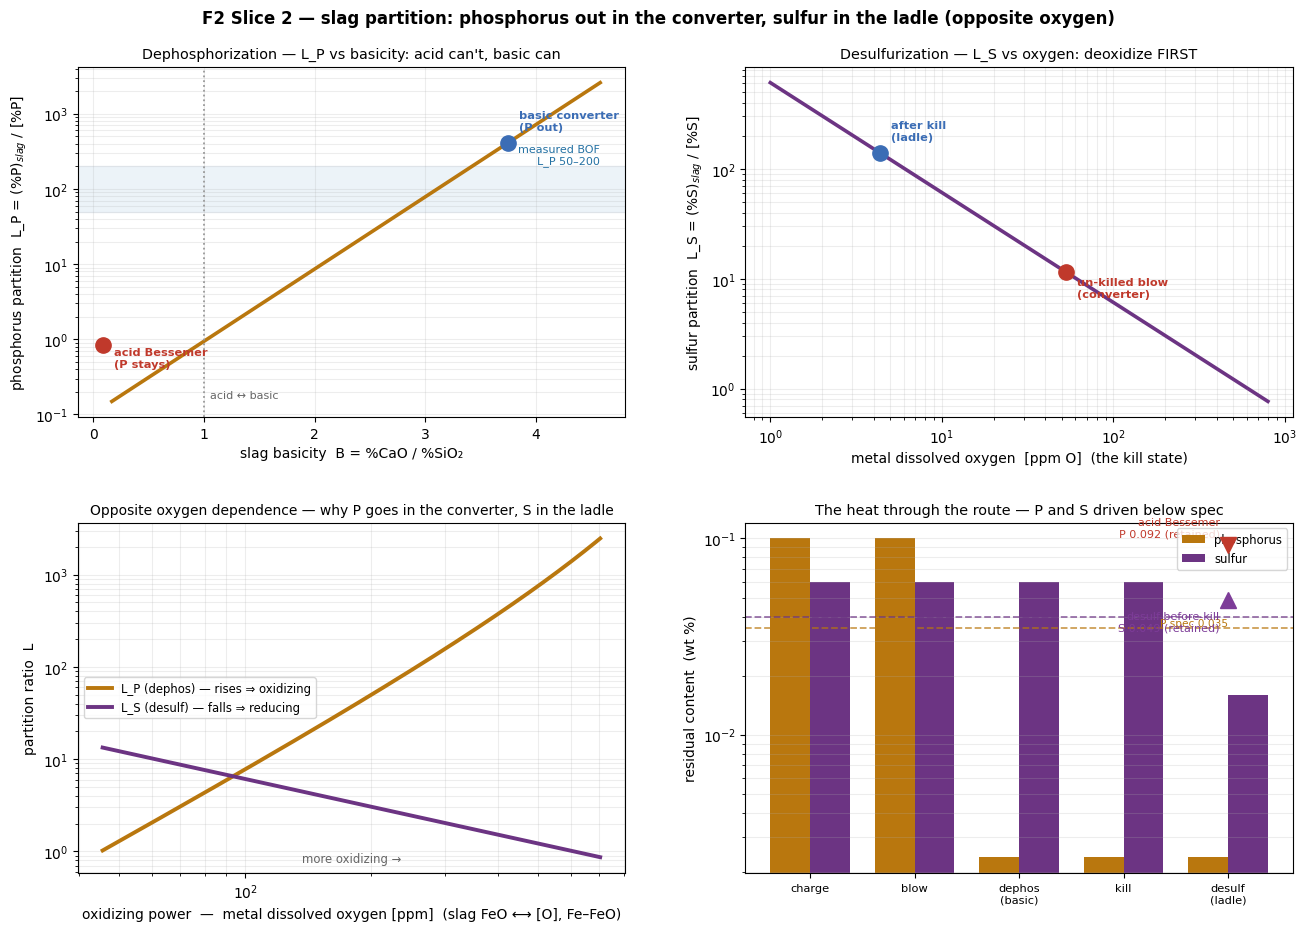

   basic converter: L_P = 411.5  → dephosphorizes — phosphorus pulled into the slag
   acid Bessemer:   L_P = 0.8  → barely dephosphorizes — phosphorus stays in the steel  (≈486× weaker on P)
   sulfur wants a killed, low-oxygen bath: L_S = 517.2  (at 30 ppm O)


In [8]:
from steel.demo_slag import compute as slag_compute

fig = plots.slag_figure(slag_compute())              # L_P vs basicity, L_S vs dissolved oxygen
plt.show()

basic = M.slag_partition_readout(M.sl.BASIC_CONVERTER_SLAG.name, 30.0)
acid  = M.slag_partition_readout(M.sl.ACID_BESSEMER_SLAG.name, 30.0)
print(f"   basic converter: {basic['L_P_str']}  → {basic['dephos_verdict']}")
print(f"   acid Bessemer:   {acid['L_P_str']}  → {acid['dephos_verdict']}  (≈{basic['L_P']/max(acid['L_P'],1e-9):.0f}× weaker on P)")
print(f"   sulfur wants a killed, low-oxygen bath: {basic['L_S_str']}")

In [9]:
# Live: pick a refining slag and a dissolved-oxygen level; read both partitions.
def _slag(slag_name, O_ppm):
    r = M.slag_partition_readout(slag_name, float(O_ppm))
    print(f"{r['slag_label']}  —  {r['basicity_str']}")
    print(f"   phosphorus {r['L_P_str']}  → {r['dephos_verdict']}")
    print(f"   sulfur     {r['L_S_str']}  (rises as oxygen falls — a killed ladle desulfurizes best)")

interact(_slag,
         slag_name=widgets.Dropdown(options=list(M.SLAGS), value=M.sl.BASIC_CONVERTER_SLAG.name,
                                    description="slag"),
         O_ppm=widgets.FloatSlider(value=30.0, min=M.SLAG_O_MIN, max=M.SLAG_O_MAX, step=1.0,
                                   description="O ppm", continuous_update=False, style={"handle_color": KNOB}));

interactive(children=(Dropdown(description='slag', index=1, options=('acid Bessemer', 'basic converter (Thomas…

## §F3 · Ladle trim — add the alloys, and recovery decides whether it lands

This is the seam to the back end: the [ladle demo](demo_ladle.py) trims an alloy-lean tap **up to a
grade** by adding ferroalloys, sized for an *assumed* recovery (the fraction of each addition that
survives oxidation). The hero off-spec input is **produced, not hand-set**: an under-killed bath that
under-delivers on Cr/Mo lands the heat **below the cited 4140 window** — F3 flags *off-grade*, the
front-end early warning — and then the *same* oil quench leaves a **soft core**, the validated back-end
consequence. One ladle mistake, two flags.

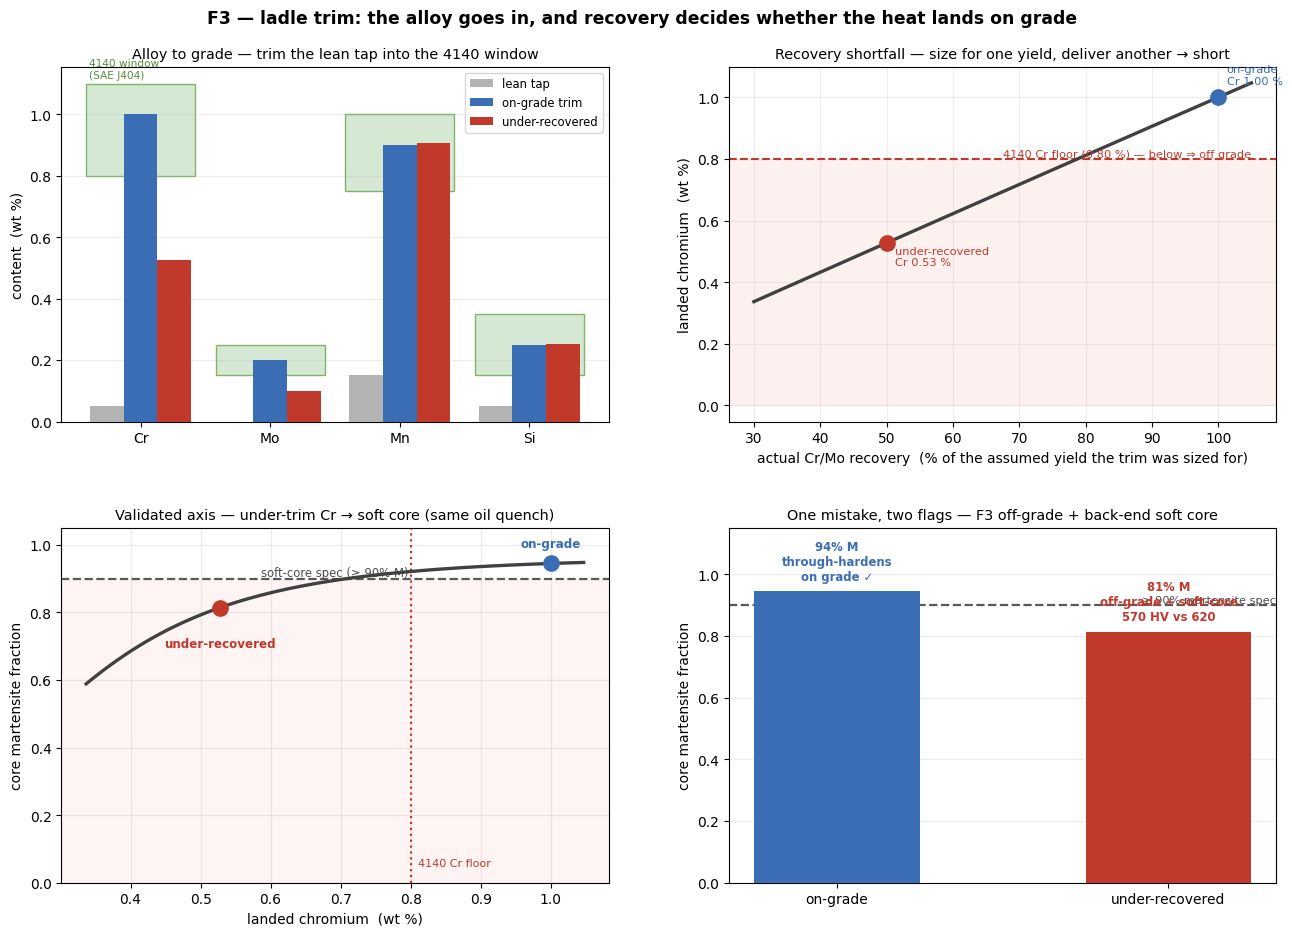

   ✓ full recovery: on grade — Cr clears the 0.80 % floor of the 4140 window  (94% martensite, 620 HV)
   ✗ half recovery: OFF GRADE — Cr, Mo outside the 4140 window (Cr floor 0.80 %)
      …and it soft-cores at the quench (81% martensite, 570 HV) — one mistake, two flags.


In [10]:
from steel.demo_ladle import compute as ladle_compute

fig = plots.ladle_figure(ladle_compute())            # naive vs recovery-corrected trim → off-grade + soft core
plt.show()

full  = M.ladle_trim_readout(1.0)                    # bath delivers the assumed recovery
short = M.ladle_trim_readout(0.5)                    # bath under-delivers Cr/Mo by half
print(f"   {_mark(full['off_grade'])} full recovery: {full['grade_verdict']}  ({full['martensite_str']})")
print(f"   {_mark(short['off_grade'])} half recovery: {short['grade_verdict']}")
if short['soft_core']:
    print(f"      …and it soft-cores at the quench ({short['martensite_str']}) — one mistake, two flags.")

In [11]:
# Live: scale the Cr/Mo recovery the bath actually delivers, against the assumed yield the additions were sized for.
def _ladle(recovery):
    r = M.ladle_trim_readout(float(recovery))
    print(f"{_mark(r['off_grade'])} {r['grade_verdict']}")
    print(f"   landed {r['landed_str']}  →  {r['martensite_str']}"
          + ("   — soft core, the same shortfall, the downstream consequence" if r['soft_core'] else ""))

interact(_ladle,
         recovery=widgets.FloatSlider(value=1.0, min=M.LADLE_RECOVERY_MIN, max=M.LADLE_RECOVERY_MAX, step=0.05,
                                      description="Cr/Mo recovery", continuous_update=False,
                                      style={"handle_color": KNOB}));

interactive(children=(FloatSlider(value=1.0, continuous_update=False, description='Cr/Mo recovery', max=1.05, …

## §F3b · Carbon carry-in — the *same* trim, but the ferroalloy carbon grade decides

A *second*, independent way the ladle trim lands off-grade — not the recovery shortfall above, but the
carbon the ferroalloys themselves carry. The cheap charge-grade ferrochrome / ferromanganese run
~6–8 % C, so trimming a 4140 tap with them drags **~+0.18 %C** in — off the grade's own carbon window
and into an over-hard steel; the refined low-carbon ferroalloys (the reason they exist, and cost more)
hold the aim. One trim, the alloy *grade* decides — mass-balance over cited assays, no fitted constant.

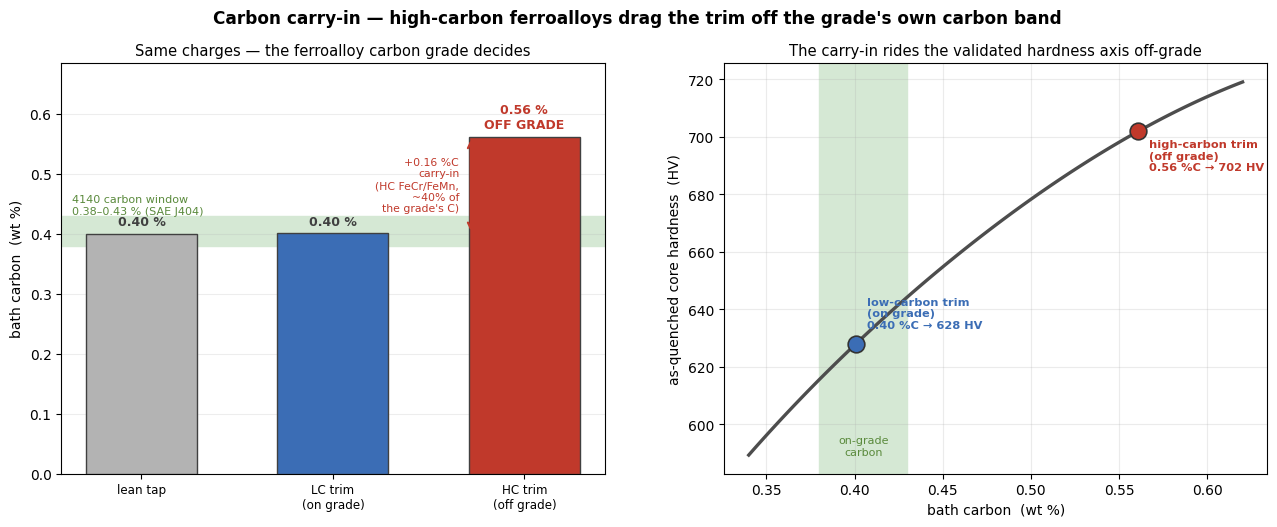

   ✗ high-carbon ferroalloys: 0.56 %C  (window 0.38–0.43 %)  →  91% M, 702 HV
   ✓ low-carbon ferroalloys:  0.40 %C  (window 0.38–0.43 %)  →  94% M, 628 HV
   the charge-grade alloys carry +0.18 %C from the ferroalloys — ~40 % of the grade's own carbon: the same trim, off-grade.


In [2]:
from steel.demo_carbon_carry_in import compute as ci_compute

fig = plots.carbon_carry_in_figure(ci_compute())     # HC vs LC ferroalloys → carbon → hardness
plt.show()

hi = M.ladle_carbon_carryin_readout(False)           # cheap high-carbon (charge-grade) ferroalloys
lo = M.ladle_carbon_carryin_readout(True)            # refined low-carbon ferroalloys
print(f"   {_mark(hi['off_grade'])} high-carbon ferroalloys: {hi['landed_str']}  →  {hi['hardness_str']}")
print(f"   {_mark(lo['off_grade'])} low-carbon ferroalloys:  {lo['landed_str']}  →  {lo['hardness_str']}")
print(f"   the charge-grade alloys carry {hi['pickup_str']} — ~40 % of the grade's own carbon: the same trim, off-grade.")

In [3]:
# Live: switch the ferroalloy carbon grade — cheap high-carbon (charge-grade) vs refined low-carbon.
def _carryin(ferroalloys):
    r = M.ladle_carbon_carryin_readout(ferroalloys)
    print(f"{_mark(r['off_grade'])} {r['grade_verdict']}")
    print(f"   landed {r['landed_str']}  →  {r['hardness_str']}  ({r['pickup_str']})")

interact(_carryin,
         ferroalloys=widgets.Dropdown(options=[("high-carbon (charge-grade, ~6–8 %C)", False),
                                                ("low-carbon (refined)", True)],
                                      value=False, description="ferroalloys"));

interactive(children=(Dropdown(description='ferroalloys', options=(('high-carbon (charge-grade, ~6–8 %C)', Fal…

## §F3c · Deox → recovery — the kill's leftover oxygen taxes the oxidizable alloys

The seam from F2's deox state into F3's recovery: the dissolved oxygen the kill leaves does not vanish
when the alloys go in — it ties up a stoichiometric mass of the **oxidizable** trim elements (Mn, Si)
as oxide, so they land below nominal, while the **noble** Cr/Mo/Ni are oxygen-independent. *Kill before
you trim.* The effect is honest but **modest** — sub-window at these carbons — which is exactly *why*
the gross under-trim hero in §F3 has to be hand-set: the dissolved-O coupling alone cannot drive a heat
off grade.

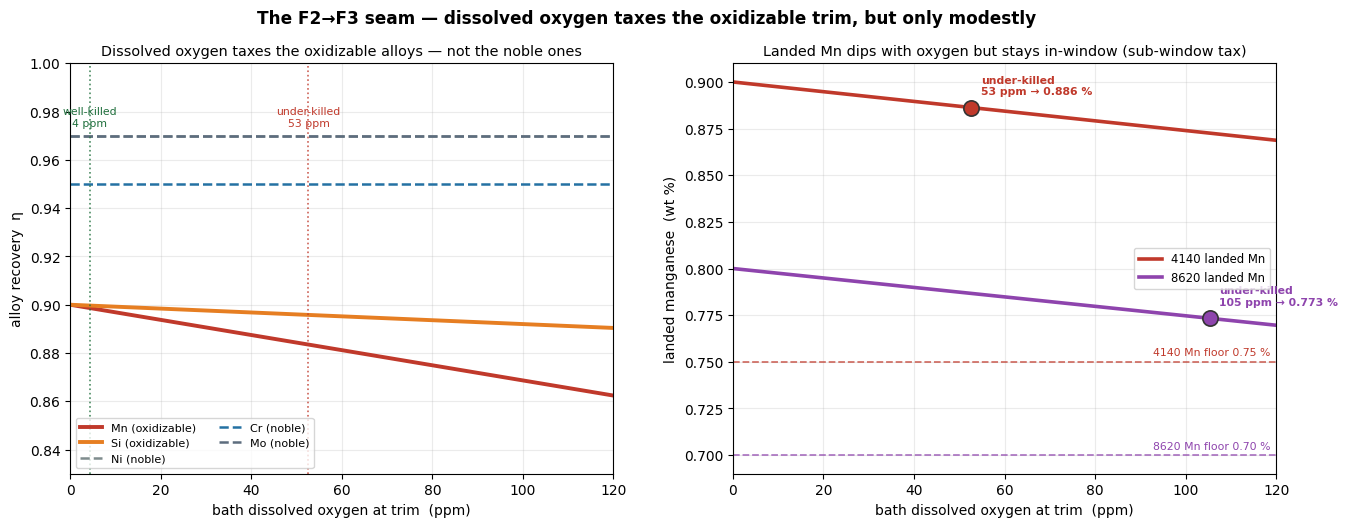

   Al — proper kill (0.04 %)
      4 ppm O after the Al kill;  Mn recovery −0.2 % (Si −0.0 %);  Mn 0.90 %  (window floor 0.75 %) — in-band
   Si — insufficient kill (0.05 %)
      53 ppm O after the Si kill;  Mn recovery −1.8 % (Si −0.5 %);  Mn 0.89 %  (window floor 0.75 %) — in-band  ⚠ porosity-risk (F2's own flag)
   both land in-band: the coupling is sub-window — a readout contrast, not an off-grade flag.


In [4]:
from steel.demo_deox_recovery import compute as dr_compute

fig = plots.deox_recovery_figure(dr_compute())       # recovery vs dissolved O; landed Mn per grade
plt.show()

for kill in M.DEOX_KILLS:                             # a proper Al kill vs an insufficient Si one
    r = M.ladle_deox_recovery_readout(kill)
    band = "in-band" if r['in_band'] else "OUT of band"
    flag = "  ⚠ porosity-risk (F2's own flag)" if r['porosity_risk'] else ""
    print(f"   {kill}")
    print(f"      {r['oxygen_str']};  {r['tax_str']};  {r['landed_str']} — {band}{flag}")
print("   both land in-band: the coupling is sub-window — a readout contrast, not an off-grade flag.")

In [5]:
# Live: pick the deoxidation before the trim — a proper Al kill vs an insufficient Si one.
def _deox(kill):
    r = M.ladle_deox_recovery_readout(kill)
    print(r['verdict'])
    print(f"   {r['oxygen_str']}   |   {r['tax_str']}   |   {r['landed_str']}"
          + ("   ⚠ porosity-risk" if r['porosity_risk'] else ""))

interact(_deox,
         kill=widgets.Dropdown(options=list(M.DEOX_KILLS), value=list(M.DEOX_KILLS)[0],
                               description="deox kill"));

interactive(children=(Dropdown(description='deox kill', options=('Al — proper kill (0.04 %)', 'Si — insufficie…

## §F4a · Casting — freeze the billet, and segregation locks in a hard band

The chain closes front-to-back at casting. As the billet freezes, **Scheil microsegregation** enriches
the last-to-freeze **centerline** in solutes (S, P, C the worst), so the *same* casting is no longer
uniform: the [casting demo](demo_casting.py) threads both the nominal section and the enriched centerline
through the back end, and the centerline **over-hardens into a hard band** the bulk never reaches —
uneven hardenability, straight from segregation feeding the validated back end. Chvorinov's `t ∝ M²`
sets how long the section takes to freeze.

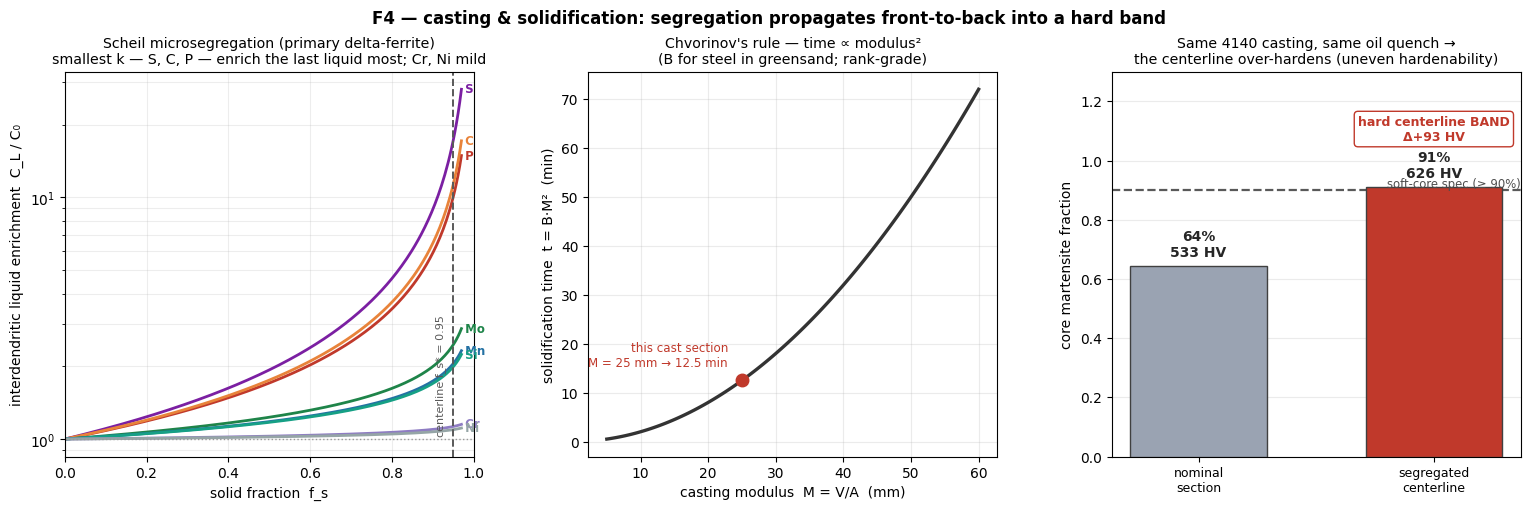

   4140 cast at 25 mm modulus, solidifies in 750 s (12.5 min):
      nominal section:     64% M, 533 HV
      enriched centerline: 91% M, 626 HV   →  +93 HV harder centerline band
   centerline enrichment of the substitutional alloys: Mn ×1.56, Si ×1.53, Cr ×1.08, Mo ×1.72


In [12]:
from steel.demo_casting import compute as cast_compute

fig = plots.casting_figure(cast_compute())           # Scheil enrichment → nominal vs centerline heat-treat
plt.show()

cr = M.casting_readout(M.CAST_GRADE, 25.0)           # 4140, 25 mm modulus
print(f"   {M.CAST_GRADE} cast at 25 mm modulus, solidifies in {cr['chvorinov_str']}:")
print(f"      nominal section:     {cr['nominal_str']}")
print(f"      enriched centerline: {cr['centerline_str']}   →  {cr['band_str']}")
print("   centerline enrichment of the substitutional alloys: "
      + ", ".join(f"{el} ×{r:.2f}" for el, r in cr['centerline_ratios'].items()))

In [13]:
# Live: change the casting modulus (V/A); read the centerline band the same casting hardens into.
def _cast(modulus_mm):
    r = M.casting_readout(M.CAST_GRADE, float(modulus_mm))
    print(f"{M.CAST_GRADE} at {modulus_mm:.0f} mm modulus  —  freezes in {r['chvorinov_str']}")
    print(f"   nominal {r['nominal_str']}   vs   centerline {r['centerline_str']}   →  {r['band_str']}")

interact(_cast,
         modulus_mm=widgets.FloatSlider(value=25.0, min=M.CAST_MODULUS_MIN_MM, max=M.CAST_MODULUS_MAX_MM,
                                        step=1.0, description="modulus mm", continuous_update=False,
                                        style={"handle_color": KNOB}));

interactive(children=(FloatSlider(value=25.0, continuous_update=False, description='modulus mm', max=60.0, min…

## §F4b · Solidification — the latent-heat field, validated against the Stefan solution

Casting's deferred half: the [solidification demo](demo_solidification.py) solves the **latent-heat
temperature field** of a section freezing against a chill, on the *same sealed heat engine* (enthalpy
method, no engine touch). The headline **tooth** is that the numerical freezing front *converges to the
analytic one-phase Stefan closed form* `2λ√(αt)` under grid refinement, with enthalpy conserved to the
residual below. The insulated **centre freezes last** — the shrinkage hot spot, the same centerline
§F4a enriches and where porosity (§D5) and hot-tears (§D6) nucleate. This is the one heavy solve in the
notebook (a few seconds), so it is shown as a banked static figure — its live section/chill knobs live
in the app.

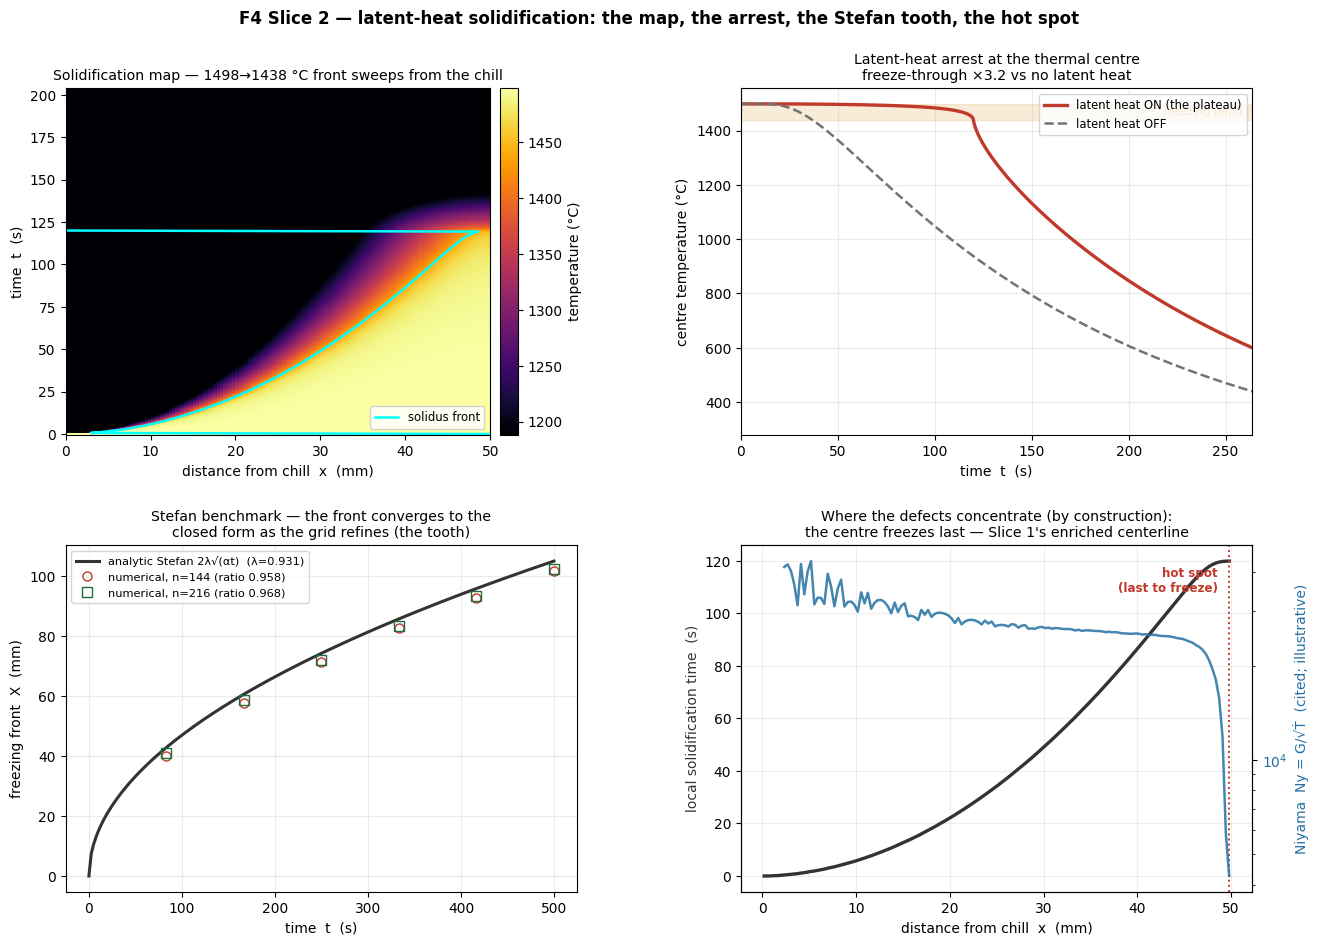

   centre freezes last (with transform): 120 s
   enthalpy conservation residual:       4.3e-13  (exact, not a fit)
   the moving front is validated against the analytic one-phase Stefan solution (the figure overlay).


In [14]:
from steel.demo_solidification import compute as sol_compute

d = sol_compute()                                    # the latent-heat chill-slab solve (banked static)
fig = plots.solidification_figure(d)
plt.show()

print(f"   centre freezes last (with transform): {d.centre_freeze_on:,.0f} s")
print(f"   enthalpy conservation residual:       {d.conservation_resid:.1e}  (exact, not a fit)")
print("   the moving front is validated against the analytic one-phase Stefan solution (the figure overlay).")

# …and here is what goes wrong

The making chain set the chemistry; this half is what it comes back to inflict. Every defect below
shares the **two-tier** shape: an upstream stage sets a flat, single-number **risk** (O > 30 ppm,
S > 0.040 %, H > 2 ppm, a J-factor); whether a *part* actually **fails** is the **consequence** —
carbon-aware, geometry-aware, or segregation-aware — and the two routinely disagree. The recurring
punchline: **same impurity, the *other* variable decides.** (These live as a separate Streamlit app,
`app_consequences.py`; here they close the front-end story.)

The last three turn the screw: peritectic cracking is **non-monotonic** in carbon (more carbon is
*safer*), and the two *signed* foils — free-machining MnS and Damascus carbide banding — are cases
where the "impurity" is on purpose, an asset and a liability at once.

## §D1 · Phosphorus & sulfur — the impurity window (cold-short ↔ red-short)

The two tramp impurities §F2b partitioned, now doing their damage from **opposite ends** of the
temperature window. At the **cold** end, phosphorus threads the existing Pickering DBTT law — it
*strengthens **and** embrittles* (the signed-impurity foil), so an off-spec heat is brittle **in the
hand** (cold-short). At the **hot** end, the free sulfur that manganese did *not* tie up as benign MnS
forms a Fe–FeS grain-boundary film above the ~988 °C eutectic, so the steel **tears when forged**
(red-short — Mushet's manganese is the cure). Together they bracket the workable window.

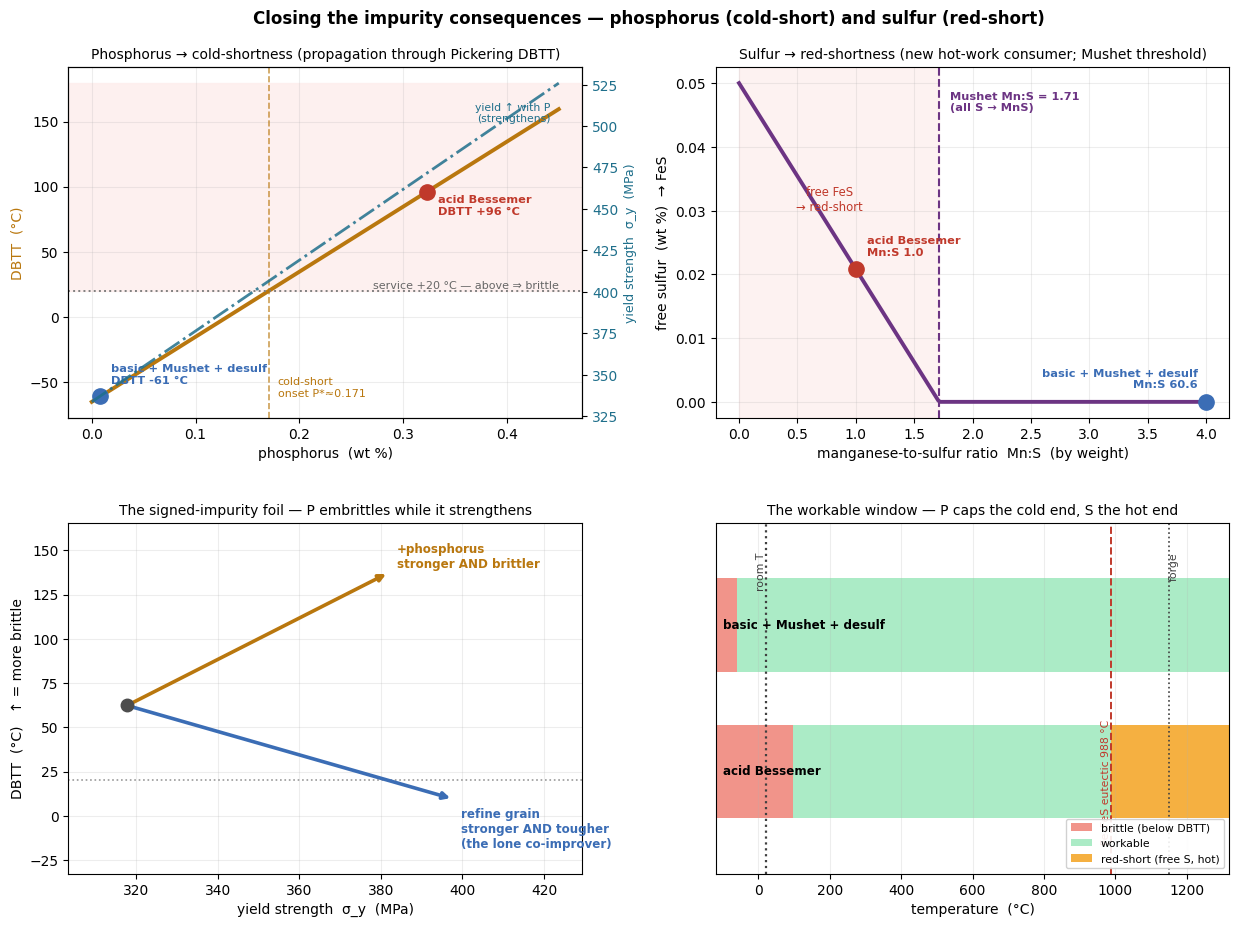

   ✗ cold end: COLD-SHORT — brittle in the hand (DBTT +85 °C is above the +20 °C service temperature)
   ✗ hot end:  RED-SHORT — tears when forged (0.021 % free sulfur films the grain boundaries above the 988 °C eutectic)
   yield (the foil): 447 MPa  — phosphorus raises strength AND the DBTT


In [15]:
from steel.demo_impurity_window import compute as imp_compute

fig = plots.impurity_window_figure(imp_compute())    # DBTT vs P and free-sulfur vs Mn:S, the bracketed window
plt.show()

r = C.impurity_readout(0.30, 0.05, 0.05)             # high P, low Mn, sulfurous — both ends fail
print(f"   {_mark(r['cold_short'])} cold end: {r['cold_verdict']}")
print(f"   {_mark(r['red_short'])} hot end:  {r['red_verdict']}")
print(f"   yield (the foil): {r['yield_str']}  — phosphorus raises strength AND the DBTT")

In [16]:
# Live: P (cold end), Mn (the Mushet lever), S (hot end) — find the workable window.
def _imp(P, Mn, S):
    r = C.impurity_readout(P, Mn, S)
    print(f"{_mark(r['cold_short'])} {r['cold_verdict']}")
    print(f"{_mark(r['red_short'])} {r['red_verdict']}")

interact(_imp,
         P=widgets.FloatSlider(value=0.30, min=C.IMP_P_MIN, max=C.IMP_P_MAX, step=0.01,
                               description="P %", continuous_update=False, style={"handle_color": KNOB}),
         Mn=widgets.FloatSlider(value=0.05, min=C.IMP_MN_MIN, max=C.IMP_MN_MAX, step=0.05,
                                description="Mn %", continuous_update=False, style={"handle_color": KNOB}),
         S=widgets.FloatSlider(value=0.05, min=C.IMP_S_MIN, max=C.IMP_S_MAX, step=0.005,
                               description="S %", continuous_update=False, style={"handle_color": KNOB}));

interactive(children=(FloatSlider(value=0.3, continuous_update=False, description='P %', max=0.45, step=0.01, …

## §D2 · Temper embrittlement — the reversible Ni-Cr phosphorus trap

Phosphorus' *other* consequence, on the quench-and-tempered (martensitic) path. A dirty Ni-Cr forging
with residual phosphorus and **no molybdenum**, slow-cooled through ~375–575 °C, segregates phosphorus
to the prior-austenite grain boundaries and fractures intergranularly. The
[demo](demo_temper_embrittlement.py) shows four independent cures: a **fast cool** through the window,
**~0.5 % molybdenum** (it scavenges the phosphorus — why Ni-Cr forgings get a Mo addition), a **clean
heat** (low Watanabe J-factor), or a **reheat above 600 °C** (the *reversibility* that names it). No
strict tooth — the segregation-nose gate was run on paper and could not be pinned.

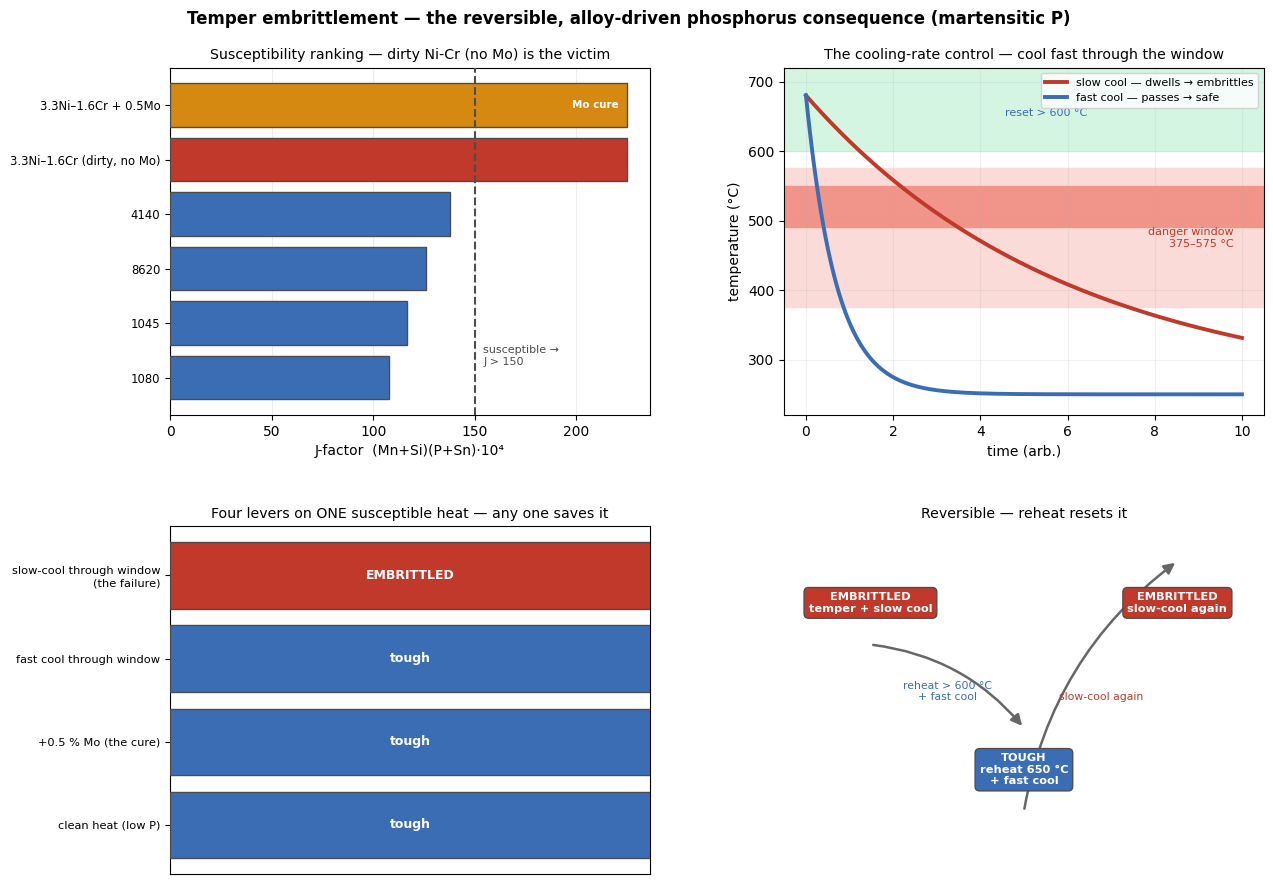

   ✗ J = 180 (susceptible above 150): TEMPER-EMBRITTLED — phosphorus segregated to the prior-austenite boundaries; the fracture turns intergranular
   ✓ + 0.5 % Mo: tough — no embrittling phosphorus segregation on this schedule  (Mo scavenges the phosphorus (the cure))
   375–575 °C danger window; reheat above 600 °C resets it


In [17]:
from steel.demo_temper_embrittlement import compute as te_compute

fig = plots.temper_embrittlement_figure(te_compute())   # J-factor + the four cures + the reversibility
plt.show()

bad  = C.temper_embrittlement_readout(0.020, 0.0, True, 500.0)    # dirty, no Mo, slow cool → trapped
cure = C.temper_embrittlement_readout(0.020, 0.50, True, 500.0)   # + 0.5 % Mo, the classic cure
print(f"   {_mark(bad['embrittled'])} {bad['J_str']}: {bad['verdict']}")
print(f"   {_mark(cure['embrittled'])} + 0.5 % Mo: {cure['verdict']}  ({cure['why']})")
print(f"   {bad['window_str']}")

In [18]:
# Live: residual P, the Mo cure, cool rate through the window, and the temper/exposure temperature.
def _te(P, Mo, slow_cool, exposure):
    r = C.temper_embrittlement_readout(P, Mo, slow_cool, exposure)
    print(f"{_mark(r['embrittled'])} {r['verdict']}")
    print(f"   {r['J_str']}  — {r['why']}")

interact(_te,
         P=widgets.FloatSlider(value=0.020, min=C.TE_P_MIN, max=C.TE_P_MAX, step=0.001, readout_format=".3f",
                               description="P %", continuous_update=False, style={"handle_color": KNOB}),
         Mo=widgets.FloatSlider(value=0.0, min=C.TE_MO_MIN, max=C.TE_MO_MAX, step=0.05,
                                description="Mo % (cure)", continuous_update=False, style={"handle_color": KNOB}),
         slow_cool=widgets.Checkbox(value=True, description="slow cool through window"),
         exposure=widgets.FloatSlider(value=500.0, min=C.TE_EXPOSURE_MIN, max=C.TE_EXPOSURE_MAX, step=10.0,
                                      description="temper °C", continuous_update=False,
                                      style={"handle_color": KNOB}));

interactive(children=(FloatSlider(value=0.02, continuous_update=False, description='P %', max=0.03, min=0.002,…

## §D3 · Tempered-martensite embrittlement — the other trough, carbon-driven & one-way

Reversible temper embrittlement has a sibling on the **same tempering axis** — and the two are
opposites. Temper as-quenched martensite in the **260–370 °C** trough and cementite precipitates as
films along the interlath boundaries; toughness drops. It is **carbon-driven**, not impurity-driven —
so a *clean* medium-carbon steel still embrittles — and it is **one-way**: temper above ~400 °C and it
recovers, but re-entering the trough cannot restore the film (the carbide morphology is set by the
*peak* temper). The [demo](demo_tempered_martensite_embrittlement.py) runs the same frozen quench the
spine uses, with two gates: enough **carbon** for the films (8620's 0.20 %C is exempt even fully
hardened) AND a **hardened martensitic** structure.

> The grade dropdown is the demo's deliberately-restricted set (4140 / 8620 / 1045) — high-carbon
> *plate*-martensite (1080) embrittles by a related but *different* mechanism, so it is excluded here
> rather than mis-attributed to the interlath-film path. The notebook imports that set straight from the
> app, so it can't drift.

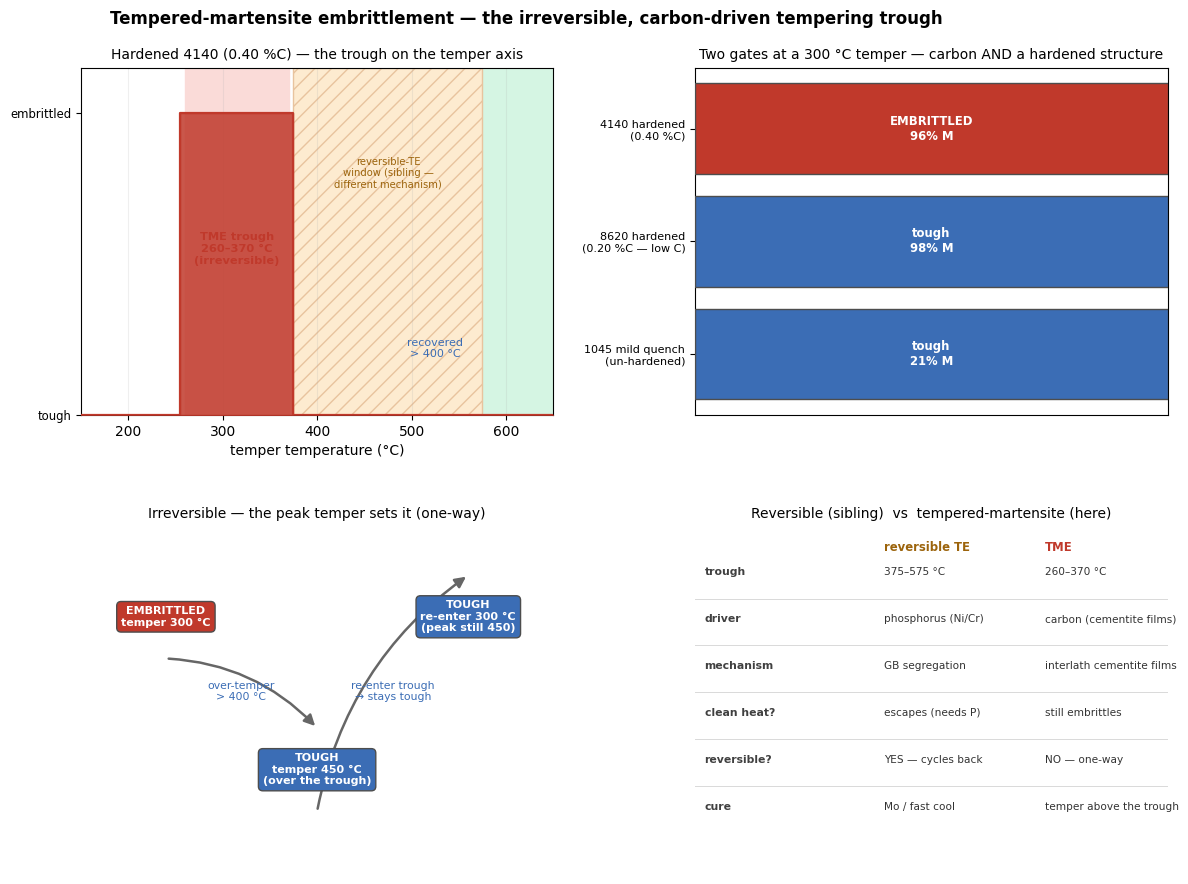

   ✗ 4140 @ 300 °C: TEMPERED-MARTENSITE EMBRITTLED — cementite films at 300 °C (inside the 260–370 °C trough)
   ✓ 8620 @ 300 °C: tough at a 300 °C peak temper  (too little carbon (0.20 %C) for the cementite films)
   the 260–370 °C trough; recovers (one-way) above 400 °C


In [19]:
from steel.demo_tempered_martensite_embrittlement import compute as tme_compute

fig = plots.tempered_martensite_embrittlement_figure(tme_compute())  # the trough, two gates, irreversibility
plt.show()

emb  = C.tme_readout("4140", 300.0)                  # medium-carbon, tempered into the trough
safe = C.tme_readout("8620", 300.0)                  # low-carbon, exempt even at the same temper
print(f"   {_mark(emb['embrittled'])} 4140 @ 300 °C: {emb['verdict']}")
print(f"   {_mark(safe['embrittled'])} 8620 @ 300 °C: {safe['verdict']}  ({safe['why']})")
print(f"   {emb['window_str']}")

In [20]:
# Live: pick a grade (its carbon) and a peak temper; read the carbon-driven, irreversible trough.
def _tme(grade, peak):
    r = C.tme_readout(grade, peak)
    print(f"{_mark(r['embrittled'])} {r['verdict']}")
    print(f"   {r['martensite_str']}  — {r['why']}")

interact(_tme,
         grade=widgets.Dropdown(options=list(C.TME_GRADES), value="4140", description="grade"),
         peak=widgets.FloatSlider(value=300.0, min=C.TME_TEMPER_MIN, max=C.TME_TEMPER_MAX, step=10.0,
                                  description="peak temper °C", continuous_update=False,
                                  style={"handle_color": KNOB}));

interactive(children=(Dropdown(description='grade', options=('4140', '8620', '1045'), value='4140'), FloatSlid…

## §D4 · Hydrogen flaking — same ladle hydrogen, the section decides

What dissolved **hydrogen** finally does — and why it is a *geometric* consequence, not a number.
Refining fills the ladle hydrogen and flags the chemistry-state risk; whether a *part* flakes (internal
hairline cracks) is set by whether the hydrogen can **diffuse out** before the section cools into the
brittle range. The [demo](demo_hydrogen_flaking.py) takes the same ~3.6 ppm 4140 and shows two sections,
same dehydrogenation bake: the thin one degasses and is sound, the heavy forging traps it and flakes —
and a long enough bake saves the thick one (the time scales as **section²**). One genuine tooth: the
bake time from an independently-pinned lattice diffusivity reproduces cited practice (a 500 mm forging →
~10 days) with no tuning.

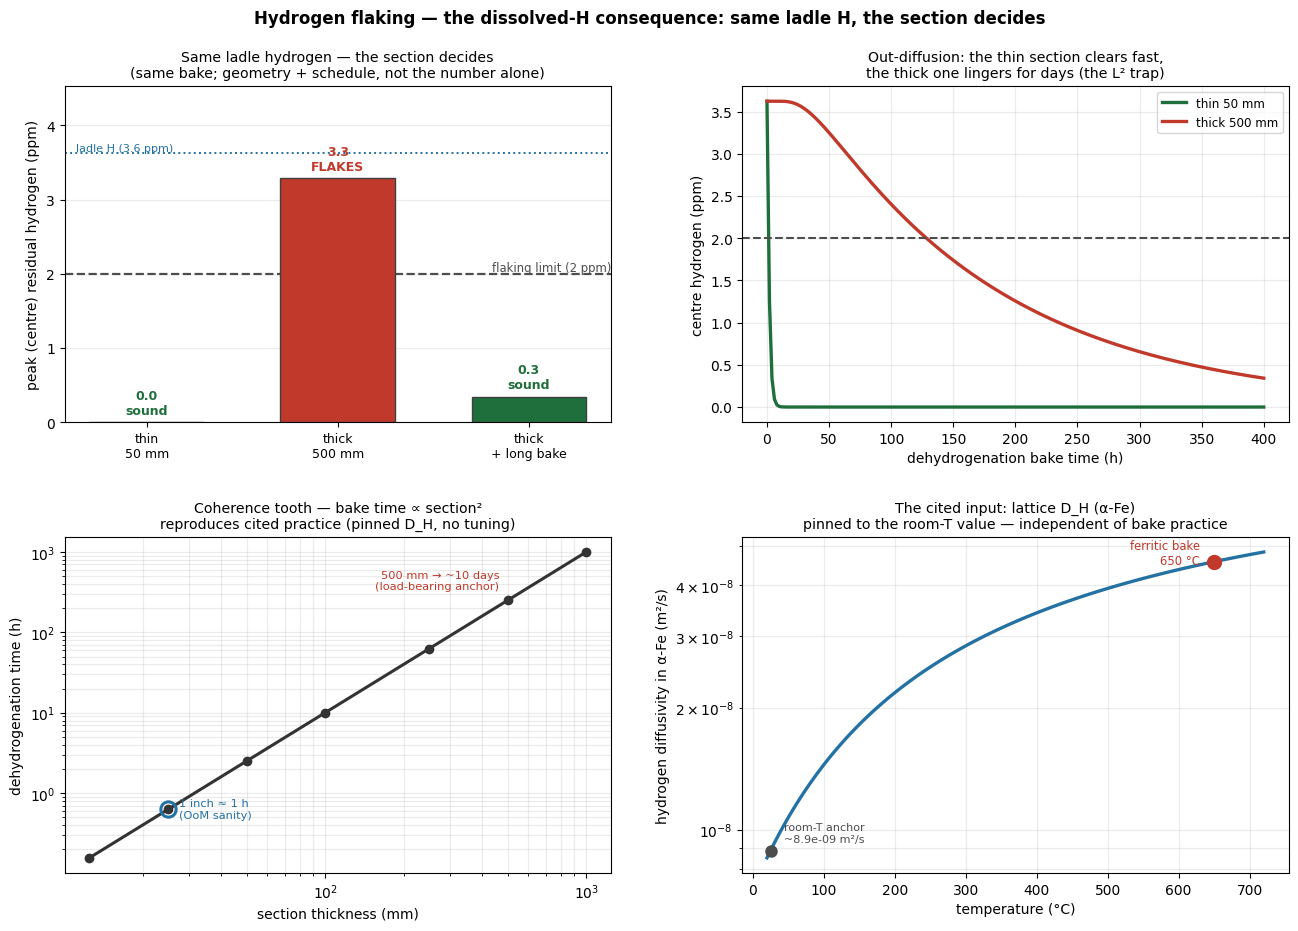

   ✗ 500 mm @ 48 h: FLAKES — the 500 mm section traps hydrogen (3.28 ppm > 2 ppm limit); internal hairline cracks
   ✓ 50 mm  @ 48 h: sound — the 50 mm section degassed to 0.00 ppm, under the limit
   3.6 ppm H from the ladle (limit 2 ppm); this section needs ~250 h to degas below the limit


In [21]:
from steel.demo_hydrogen_flaking import compute as hf_compute

fig = plots.hydrogen_flaking_figure(hf_compute())    # residual H vs bake, thin (sound) vs thick (flakes)
plt.show()

thick = C.hydrogen_flaking_readout(500.0, 48.0)      # 500 mm forging, 48 h bake — still over the limit
thin  = C.hydrogen_flaking_readout(50.0, 48.0)       # 50 mm section, same bake — degassed
print(f"   {_mark(thick['flakes'])} 500 mm @ 48 h: {thick['verdict']}")
print(f"   {_mark(thin['flakes'])} 50 mm  @ 48 h: {thin['verdict']}")
print(f"   {thick['ladle_str']}; {thick['needed_str']}")

In [22]:
# Live: section size and dehydrogenation bake — the section decides, the bake is the lever.
def _hf(section_mm, bake_h):
    r = C.hydrogen_flaking_readout(section_mm, bake_h)
    print(f"{_mark(r['flakes'])} {r['verdict']}")
    print(f"   {r['residual_str']}; {r['needed_str']}")

interact(_hf,
         section_mm=widgets.FloatSlider(value=500, min=C.HF_SECTION_MIN_MM, max=C.HF_SECTION_MAX_MM, step=10,
                                        description="section mm", continuous_update=False, style={"handle_color": KNOB}),
         bake_h=widgets.FloatSlider(value=48.0, min=C.HF_BAKE_MIN_H, max=C.HF_BAKE_MAX_H, step=4.0,
                                    description="bake h", continuous_update=False, style={"handle_color": KNOB}));

interactive(children=(FloatSlider(value=500.0, continuous_update=False, description='section mm', max=1000.0, …

## §D5 · Gas (CO) porosity — same oxygen spec, the carbon decides

What dissolved **oxygen** finally does — and why it is a *carbon-aware* consequence. Refining flags a
carbon-blind risk (O > 30 ppm); whether a *casting* blows CO holes is set by the **carbon** the oxygen
reacts with: gas evolves where `[%C]·[%O]` crosses the same CO equilibrium the converter runs on. The
[demo](demo_gas_porosity.py) shows two carbons under the *same* light kill, both within the 30 ppm spec:
the high-carbon 1080 sits right on the CO line and blows holes — carrying *less* oxygen than the sound
low-carbon 8620. A full aluminium **kill** drops the oxygen under the line and saves it. Honestly no
claimable tooth (the criterion is the cited C–O equilibrium against held composition).

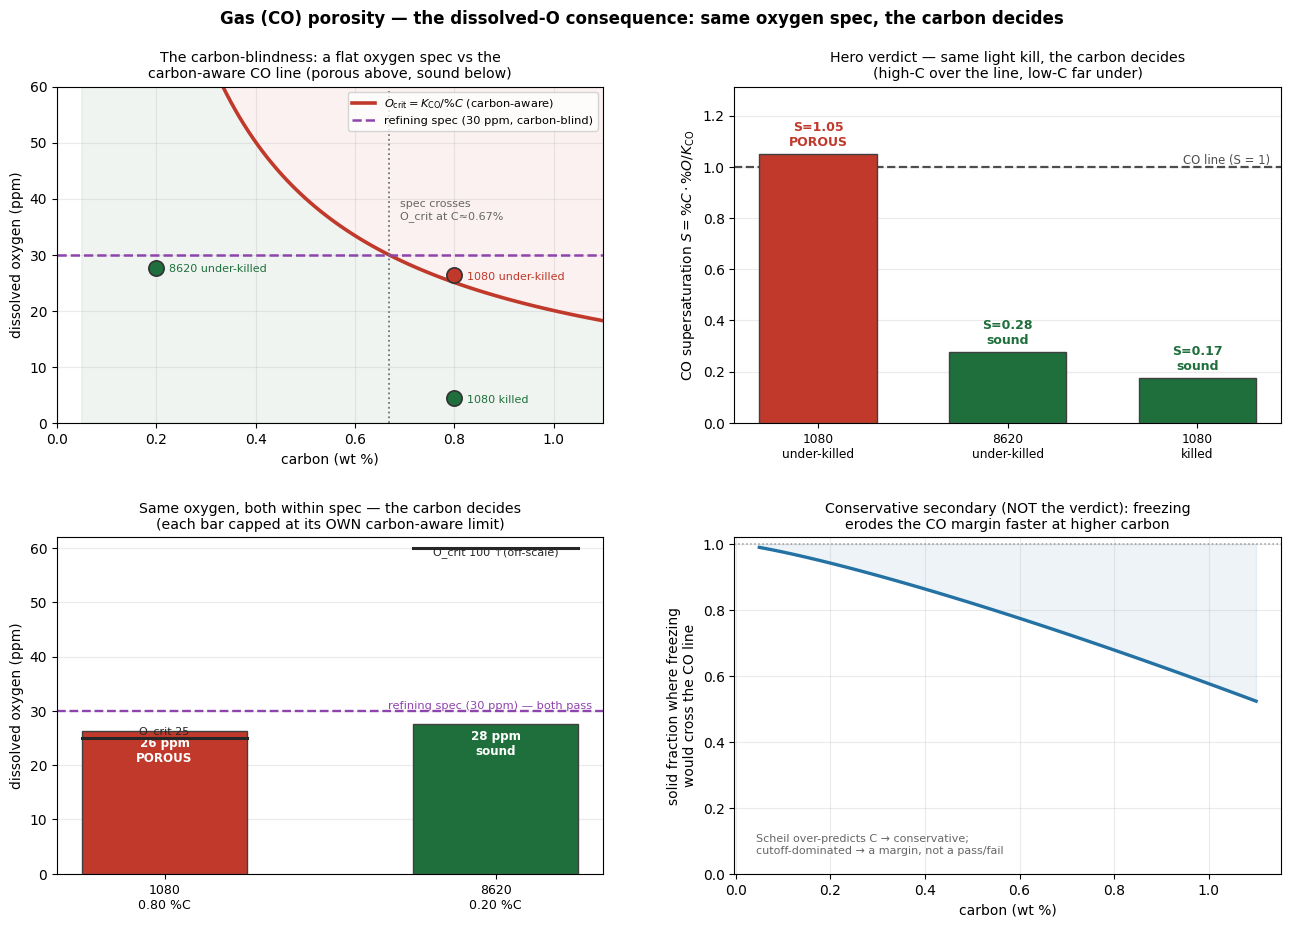

   ✗ 1080 (high C), light kill: POROUS — CO evolves (supersaturation S = 1.05 > 1); the casting blows holes
      26 ppm O at 0.80 %C (carbon-aware limit O_crit ≈ 25 ppm)  |  refining's flat risk line: O ≤ 30 ppm → cleared
   ✓ 8620 (low C),  light kill: sound — under the carbon-aware CO line (S = 0.28 ≤ 1)  — carries more oxygen, yet sound


In [23]:
from steel.demo_gas_porosity import compute as gp_compute

fig = plots.gas_porosity_figure(gp_compute())        # the carbon-decides contrast, both within spec
plt.show()

hi = C.gas_porosity_readout("1080", 0.0015)          # high carbon, light kill → porous
lo = C.gas_porosity_readout("8620", 0.0015)          # low carbon, same kill → sound
print(f"   {_mark(hi['porous'])} 1080 (high C), light kill: {hi['verdict']}")
print(f"      {hi['oxygen_str']}  |  {hi['risk_str']}")
print(f"   {_mark(lo['porous'])} 8620 (low C),  light kill: {lo['verdict']}  — carries {'more' if lo['oxygen_ppm']>hi['oxygen_ppm'] else 'similar/less'} oxygen, yet sound")

In [24]:
# Live: pick a grade (its carbon) and the aluminium kill level (the deox lever).
def _gp(grade, al):
    r = C.gas_porosity_readout(grade, al)
    print(f"{_mark(r['porous'])} {r['verdict']}")
    print(f"   {r['oxygen_str']}   |   {r['risk_str']}")

interact(_gp,
         grade=widgets.Dropdown(options=list(C.GP_GRADES), value="1080", description="grade"),
         al=widgets.FloatSlider(value=0.0015, min=C.GP_AL_MIN, max=C.GP_AL_MAX, step=0.0005, readout_format=".4f",
                                description="Al kill %", continuous_update=False, style={"handle_color": KNOB}));

interactive(children=(Dropdown(description='grade', options=('1080', '1045', '8620', '4140'), value='1080'), F…

## §D6 · Hot-tearing — same sulfur, the Mn:S in the last liquid decides

What residual **sulfur** does at the *casting* stage — the segregation-amplified sibling of forging-stage
red-shortness (distinct by **phase + time**: interdendritic liquid during freezing, not bulk solid at the
forge). Slag flags a flat, Mn-blind risk (S > 0.040 %); whether a *casting* grows a Fe–FeS interdendritic
film and tears is set by the Mn:S in the **last liquid to freeze**, which is Scheil-enriched — sulfur
piles up faster than manganese, so the film Mn:S is far poorer than the bath's. The
[demo](demo_hot_tear.py) shows two heats with the *same* sulfur: the Mushet manganese is the lever again,
only the threshold is in the **tens**, reproducing the empirical "castings need Mn:S ≳ 20" rule.

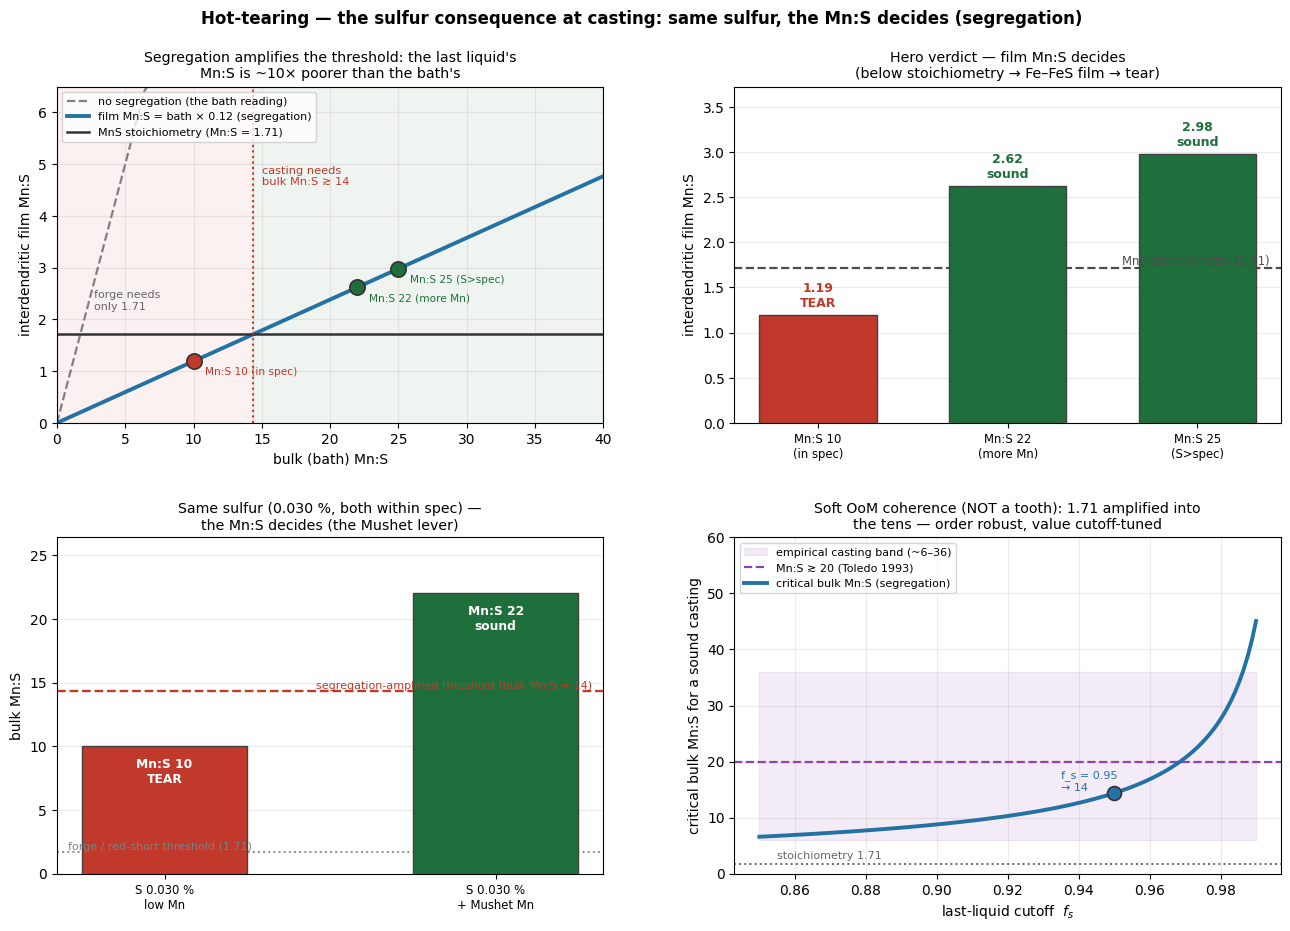

   ✗ Mn 0.30, S 0.030: HOT-TEARS — the interdendritic film Mn:S 1.19 falls below stoichiometry (1.71); a Fe–FeS film forms in the last liquid
      bulk Mn:S 10.0 → segregated film Mn:S 1.19  |  slag's flat risk line: S ≤ 0.040 % → cleared
   ✓ Mn 0.80, S 0.030: sound — the film keeps Mn:S 3.18 above 1.71 (bulk Mn:S clears the segregation-amplified ≈14 threshold)
   segregation amplifies the stoichiometric 1.71 into a bulk threshold ≈14


In [25]:
from steel.demo_hot_tear import compute as ht_compute

fig = plots.hot_tear_figure(ht_compute())            # bulk vs Scheil-enriched film Mn:S, same sulfur
plt.show()

lean = C.hot_tear_readout(0.30, 0.030)               # lower Mn → film falls below stoichiometry → tears
rich = C.hot_tear_readout(0.80, 0.030)               # higher Mn, same S → film stays sound
print(f"   {_mark(lean['hot_tear'])} Mn 0.30, S 0.030: {lean['verdict']}")
print(f"      {lean['bulk_str']}  |  {lean['risk_str']}")
print(f"   {_mark(rich['hot_tear'])} Mn 0.80, S 0.030: {rich['verdict']}")
print(f"   segregation amplifies the stoichiometric {lean['stoich']:.2f} into a bulk threshold ≈{lean['critical_bulk']:.0f}")

In [26]:
# Live: manganese (the lever) and sulfur — the film Mn:S in the last liquid decides.
def _ht(Mn, S):
    r = C.hot_tear_readout(Mn, S)
    print(f"{_mark(r['hot_tear'])} {r['verdict']}")
    print(f"   {r['bulk_str']}   |   {r['risk_str']}")

interact(_ht,
         Mn=widgets.FloatSlider(value=0.30, min=C.HT_MN_MIN, max=C.HT_MN_MAX, step=0.05,
                                description="Mn %", continuous_update=False, style={"handle_color": KNOB}),
         S=widgets.FloatSlider(value=0.030, min=C.HT_S_MIN, max=C.HT_S_MAX, step=0.005, readout_format=".3f",
                               description="S %", continuous_update=False, style={"handle_color": KNOB}));

interactive(children=(FloatSlider(value=0.3, continuous_update=False, description='Mn %', max=2.0, min=0.05, s…

## §D7 · Peritectic surface cracking — the carbon decides, and more carbon is safer

The carbon sibling of hot-tearing, but read on the **nominal** aim chemistry, never the Scheil last
liquid: the δ→γ peritectic contraction is a primary-shell phenomenon. The worst surface-crackers are
the hypo-peritectic ~0.10–0.16 %C grades; a leaner *or* a richer steel casts more soundly, so the hero
is **non-monotonic** in carbon. The verdict is Wolf's cited ferrite-potential band; the mechanism is the
Fe–C lever rule — no strict tooth. A second lever: at a fixed carbon, ferrite stabilizers (Si+Cr) pull
the carbon-equivalent into the band — same carbon, the alloying decides.

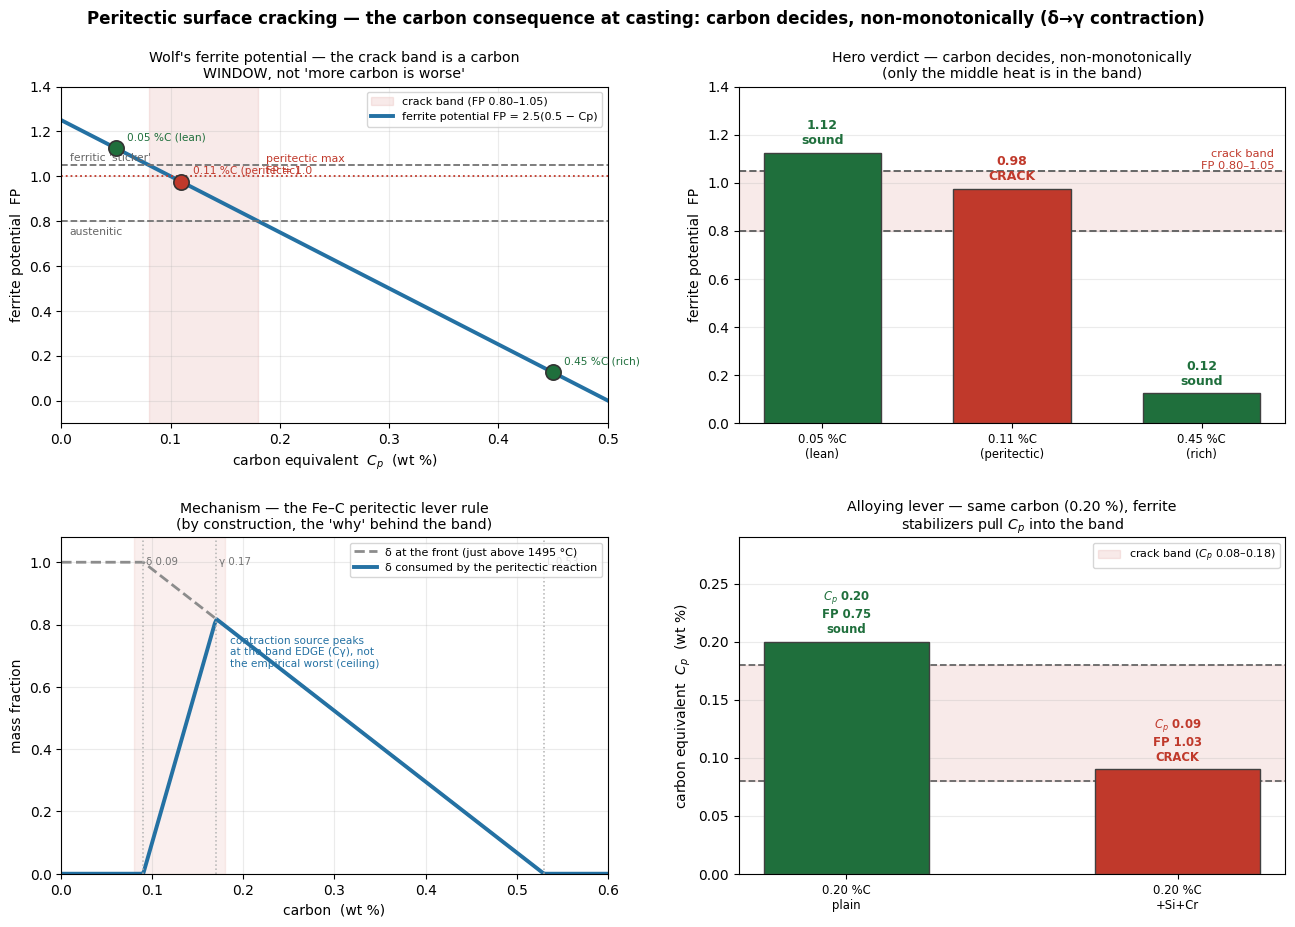

   ✓ 0.05 %C → Cp 0.05  (sub-peritectic) FP = 1.12  (crack band 0.80–1.05)
   ✗ 0.11 %C → Cp 0.11  (hypo-peritectic) FP = 0.98  (crack band 0.80–1.05)
   ✓ 0.45 %C → Cp 0.45  (hyper-peritectic) FP = 0.12  (crack band 0.80–1.05)
   only the hypo-peritectic middle cracks — a leaner OR a richer steel casts soundly: more carbon is safer.


In [6]:
from steel.demo_peritectic import compute as pk_compute

fig = plots.peritectic_figure(pk_compute())          # non-monotonic carbon; Wolf FP band; Fe–C lever rule
plt.show()

for c in (0.05, 0.11, 0.45):                         # leaner / hypo-peritectic / richer — carbon the only axis
    r = C.peritectic_readout(c, False)
    print(f"   {_mark(r['crack'])} {r['cp_str']:<34} {r['fp_str']}")
print("   only the hypo-peritectic middle cracks — a leaner OR a richer steel casts soundly: more carbon is safer.")

In [7]:
# Live: nominal carbon (the non-monotonic axis) and the Si+Cr ferrite-stabilizer lever.
def _peritectic(carbon, stabilizers):
    r = C.peritectic_readout(carbon, stabilizers)
    print(f"{_mark(r['crack'])} {r['verdict']}")
    print(f"   {r['cp_str']}   |   {r['fp_str']}   ({r['why']})")

interact(_peritectic,
         carbon=widgets.FloatSlider(value=0.11, min=C.PK_C_MIN, max=C.PK_C_MAX, step=0.01, readout_format=".2f",
                                    description="nominal C %", continuous_update=False, style={"handle_color": KNOB}),
         stabilizers=widgets.Dropdown(options=[("none", False), ("+0.5 Si +1.0 Cr", True)],
                                      value=False, description="ferrite stab."));

interactive(children=(FloatSlider(value=0.11, continuous_update=False, description='nominal C %', max=0.5, min…

## §D8 · MnS morphology — the signed sulfur foil (same MnS, asset *and* liability)

The *same* manganese sulfide is signed: a deliberate **free-machining** asset by volume (the reason the
resulfurized 11xx grades exist — MnS breaks the chip) *and* an unintended **through-thickness toughness**
liability by shape (hot working elongates it into stringers that gut the short-transverse direction).
Slag's flat `high-sulfur` risk (S > 0.040 %) fires on every free-machining grade by design; this splits
it. The hero: one resulfurized 1144 read two ways — as-rolled it is free-machining **and** anisotropic;
a calcium treatment globularizes the *same* MnS volume and it is free-machining **and** isotropic. The
lever is the **shape**, not the sulfur (which is why the anisotropy flag is gated on morphology, never an
S-threshold). A plain low-S heat is tough but cannot free-machine — the other end of the trade.

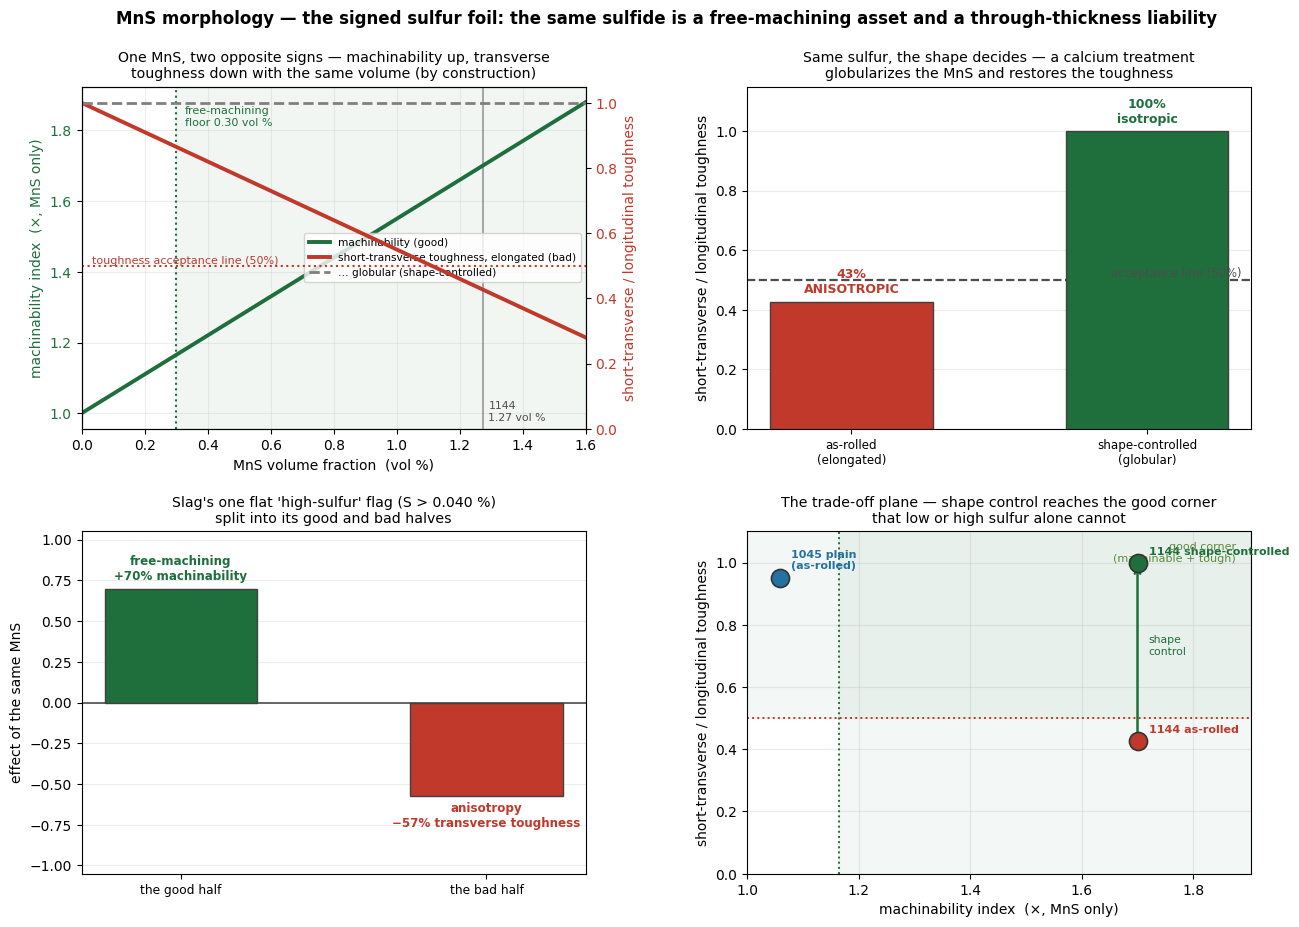

   1144, as-rolled (stringers):
      machining ✓ ×1.70  (1.27 vol % MnS)   |   toughness ✗ 43% of longitudinal  (spec ≥ 50%)
   1144, shape-controlled (Ca):
      machining ✓ ×1.70  (1.27 vol % MnS)   |   toughness ✓ 100% of longitudinal  (spec ≥ 50%)
   1045, plain: machining ✗ ×1.06  (0.11 vol % MnS) — low S buys toughness, not the chip-breaker
   same sulfur, the *shape* flips the toughness flag; only the MnS *volume* decides machining.


In [8]:
from steel.demo_sulfide_morphology import compute as sm_compute

fig = plots.sulfide_morphology_figure(sm_compute())  # same MnS: machinability asset vs toughness liability
plt.show()

resulf, plain = list(C.SM_BACKBONES)                 # the resulfurized 1144, then the plain 1045
for shape, lbl in ((False, "as-rolled (stringers)"), (True, "shape-controlled (Ca)")):
    r = C.sulfide_morphology_readout(resulf, shape)
    print(f"   1144, {lbl}:")
    print(f"      machining {_mark(not r['free_machining'])} {r['mach_str']}   |   "
          f"toughness {_mark(r['anisotropic'])} {r['transverse_str']}")
pr = C.sulfide_morphology_readout(plain, False)
print(f"   1045, plain: machining {_mark(not pr['free_machining'])} {pr['mach_str']} "
      f"— low S buys toughness, not the chip-breaker")
print("   same sulfur, the *shape* flips the toughness flag; only the MnS *volume* decides machining.")

In [9]:
# Live: pick a heat and the sulfide shape — same sulfur, morphology decides toughness (not machining).
def _sm(heat, shape):
    r = C.sulfide_morphology_readout(heat, shape)
    print(f"machining  {_mark(not r['free_machining'])} {r['free_verdict']}")
    print(f"toughness  {_mark(r['anisotropic'])} {r['aniso_verdict']}")

interact(_sm,
         heat=widgets.Dropdown(options=list(C.SM_BACKBONES), value=list(C.SM_BACKBONES)[0], description="heat"),
         shape=widgets.Dropdown(options=[("as-rolled (stringers)", False),
                                         ("shape-controlled (globular)", True)],
                                value=False, description="sulfide shape"));

interactive(children=(Dropdown(description='heat', options=('1144 — resulfurized (S ≈ 0.24 %)', '1045 — plain …

## §D9 · Wootz / Damascus banding — the trace impurity a clean spec rejects *makes* the pattern

The inversion of every panel above: the watered Damascus pattern needs a trace carbide-former
(**vanadium ≥ 40 ppm**) — the very "impurity" a modern clean-steel spec would reject as off-spec pickup.
So *bad steel* and *good steel* are the same composition, signed either way. Three gates must all hold:
**hypereutectoid carbon** (a proeutectoid cementite network to band), the **V threshold** (the trace
former), and **cyclic forging 50–100 °C below A_cm**. The flag fires *only under intent* — a heat forged
as wootz whose trace former fell short (a clean modern stock); a plain or wrongly-forged bar never
intended a pattern, so it raises none. No tooth — three cited gates over the same casting Scheil engine
the centerline defect uses, run with the opposite sign.

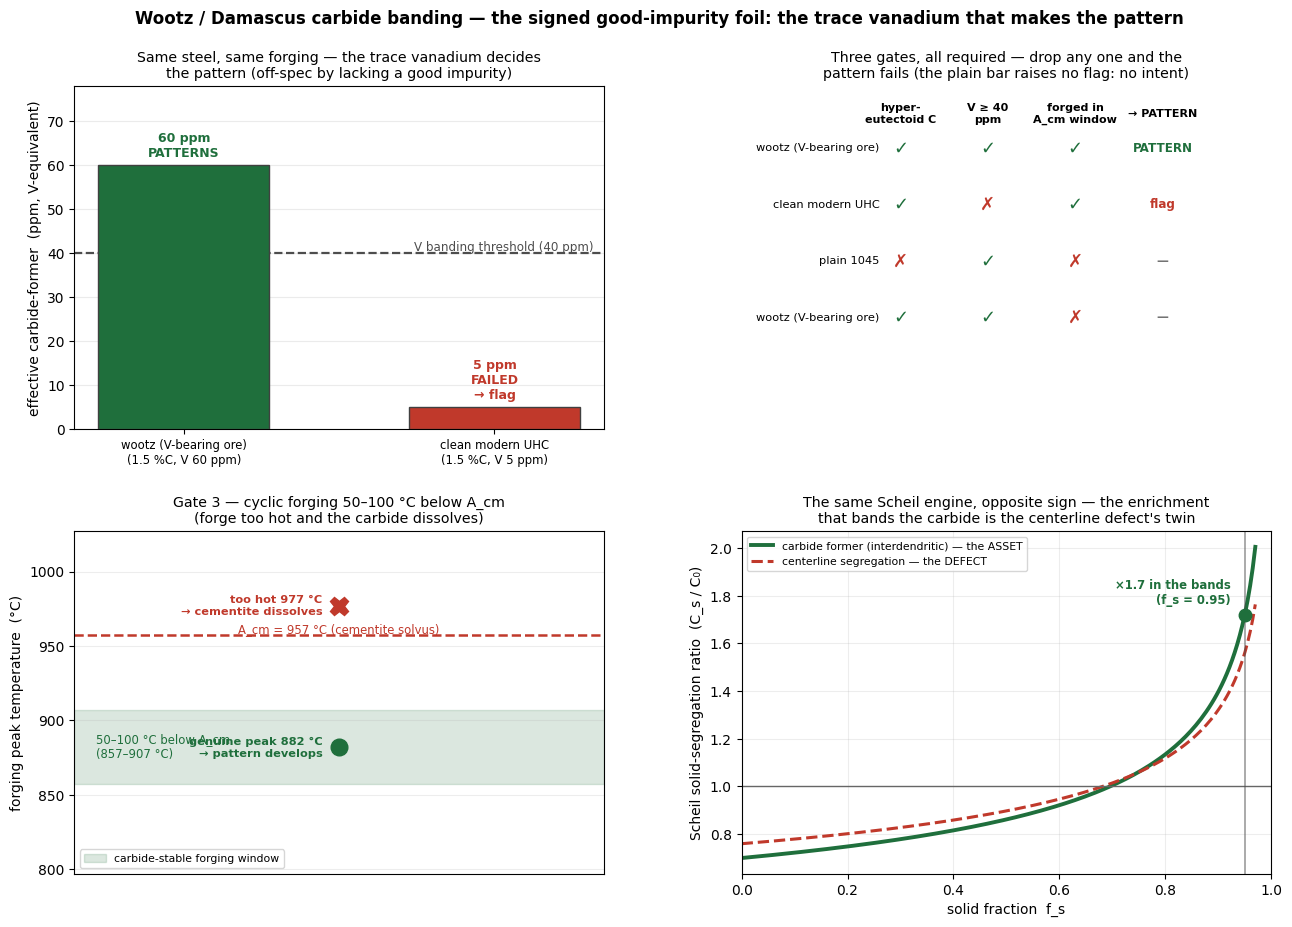

   ✓ watered  V-bearing wootz cake: 60 ppm carbide-former (V banding threshold 40 ppm)
               gates: hypereutectoid C ✓ · V ≥ 40 ppm ✓ · forged 857–907 °C ✓
   ✗ failed   clean modern twin : 5 ppm carbide-former (V banding threshold 40 ppm)
               gates: hypereutectoid C ✓ · V ≥ 40 ppm ✗ · forged 857–907 °C ✓
   · no flag  plain 0.40 %C bar : raises no flag — the pattern was never intended.


In [10]:
from steel.demo_wootz import compute as wz_compute

fig = plots.wootz_figure(wz_compute())               # trace-V three-gate; the signed Scheil enrichment
plt.show()

TIER = {"patterned": "✓ watered ", "failed": "✗ failed  ", "no-intent": "· no flag "}
for v_ppm, lbl in ((60.0, "V-bearing wootz cake"), (5.0, "clean modern twin ")):
    r = C.wootz_readout(1.5, v_ppm, 882.0)           # same 1.5 %C, same forge — only the trace V differs
    print(f"   {TIER[r['tier']]} {lbl}: {r['former_str']}")
    print(f"               gates: {r['gates_str']}")
plain = C.wootz_readout(0.40, 60.0, 882.0)           # hypo-eutectoid — never intends a pattern
print(f"   {TIER[plain['tier']]} plain 0.40 %C bar : raises no flag — the pattern was never intended.")

In [11]:
# Live: carbon, the trace vanadium (the *good* impurity), and the forging peak — all three gates must hold.
def _wz(carbon, v_ppm, forge_peak):
    r = C.wootz_readout(carbon, v_ppm, forge_peak)
    glyph = {"patterned": "✓", "failed": "✗", "no-intent": "·"}[r['tier']]
    print(f"{glyph} {r['verdict']}")
    print(f"   {r['former_str']}   |   {r['gates_str']}")

interact(_wz,
         carbon=widgets.FloatSlider(value=1.5, min=C.WZ_C_MIN, max=C.WZ_C_MAX, step=0.05, readout_format=".2f",
                                    description="carbon %", continuous_update=False, style={"handle_color": KNOB}),
         v_ppm=widgets.FloatSlider(value=60.0, min=C.WZ_V_MIN, max=C.WZ_V_MAX, step=5.0,
                                   description="trace V ppm", continuous_update=False, style={"handle_color": KNOB}),
         forge_peak=widgets.FloatSlider(value=882.0, min=C.WZ_FORGE_MIN_C, max=C.WZ_FORGE_MAX_C, step=5.0,
                                        description="forge °C", continuous_update=False, style={"handle_color": KNOB}));

interactive(children=(FloatSlider(value=1.5, continuous_update=False, description='carbon %', max=1.8, min=0.4…

## Where the numbers come from

Nothing above is computed *here*. Every figure is a banked `demo_*` artifact and every slider re-runs a
headless, validated harness — the **making** chain ([`reduction`](reduction.py), [`heat_state`](heat_state.py),
[`refining`](refining.py), [`slag`](slag.py), [`ladle`](ladle.py), [`casting`](casting.py),
[`solidification`](solidification.py)) and the **consequence** models ([`grain`](grain.py) /
[`hot_work`](hot_work.py), [`temper_embrittlement`](temper_embrittlement.py),
[`tempered_martensite_embrittlement`](tempered_martensite_embrittlement.py),
[`hydrogen_flaking`](hydrogen_flaking.py), [`gas_porosity`](gas_porosity.py), [`hot_tear`](hot_tear.py), [`peritectic`](peritectic.py), [`sulfide_morphology`](sulfide_morphology.py), [`wootz`](wootz.py)).
Each is sealed behind its own validation triad; the readout helpers this notebook calls are the *same*
ones the Streamlit apps (`app_making.py`, `app_consequences.py`) use, unit-tested always-green. This
surface adds **reach, not physics** ([ADR 0002](../docs/decisions/0002-visualization-and-ux.md)).

> **Scope, stated honestly.** The front-end wall is *transport kinetics* — equilibrium endpoints and
> lumped rates, not full process dynamics. F1 is `ΔCp = 0` Ellingham; the deoxidation curve carries the
> one Sigworth–Elliott interaction term; the slag partitions are cited correlations; casting segregation
> is Scheil (carbon held at nominal — Scheil over-predicts the interstitial). On the consequence side
> several models carry **no claimable tooth** by design (gas porosity, hot-tear, peritectic, the two
> signed foils, both temper-embrittlement troughs) — the paper-nose / carbide-kinetics gates were run and could not be pinned, so no model was
> built to manufacture a tooth; the genuine teeth (the 746 °C reduction crossover, the Al–O minimum, the
> Stefan-front convergence, the P-strength cross-source coherence, the hydrogen bake-time anchor) sit where
> the physics actually supports them. These are the same edges the harness docstrings carry — surfaced,
> not hidden.